# Credit Card Fraud Detection — Baseline Classification Models & Evaluation

**CodSoft Data Science Internship — Task 5: Credit Card Fraud Detection**
(local folder `Task3_Credit_Card_Fraud_Detection`, my own project numbering)

**Phase 3 only.** This notebook trains the two model families the CodSoft brief names — logistic
regression and random forest — under five class-imbalance strategies each, and records how every
configuration performs on the held-out test set at the **default decision threshold**.

These are **baseline** results. Nothing is tuned, no threshold is optimised, no configuration is
declared final and no model is persisted. The raw CSV is checksummed at the start and again at
the end.

---
## 1. Phase 3 Introduction

### What this phase answers

1. How does logistic regression perform on fraud?
2. How does random forest perform on fraud?
3. How does class weighting compare with training on the original imbalance?
4. How do the training-only resampling strategies behave?
5. What precision / recall / F1 trade-offs appear?
6. Which configuration provides the strongest baseline *evidence*, and under which metric?
7. What errors are being made, and do the missed frauds share a descriptive pattern?

### What carries over from Phases 1–2

| From | Fact used here |
|---|---|
| Phase 1 | Accuracy of an always-legitimate model is ~99.83% — accuracy cannot be the headline metric |
| Phase 1 | Strongest marginal class separation lies in `V17`, `V14`, `V12`, `V10` — used descriptively in the error analysis only |
| Phase 2 | Deduplicated data: 283,726 rows; stratified 80/20 split, `random_state=42` |
| Phase 2 | Train 226,980 rows (378 fraud); test 56,746 rows (95 fraud) — **re-verified below, not assumed** |
| Phase 2 | `build_preprocessor("standard")` — `StandardScaler` on all 30 features, fitted on training data only |
| Phase 2 | `build_resampler(...)` — samplers sit inside an `imblearn` pipeline so they only ever see `fit` data |

### The test-set rule, and the selection-bias rule

The test set is a **holdout**. It is used for exactly two calls per configuration — `predict_proba`
and `predict` — after fitting is complete. It is never passed to `fit`, never resampled, never used
to compute class weights, and never used to pick a threshold.

The ten configurations below were **fixed before any test result was seen**: library defaults plus
the settings needed for convergence and determinism. They were not adjusted afterwards. That matters
because the test set can only give an unbiased estimate once: change a model because of its test
score, re-score it, and the second number is no longer an estimate of anything. **These Phase 3 test
numbers are therefore an initial baseline record**, and every later selection or tuning decision
(Phase 4) must be made with cross-validation on the training split.

### Pre-registered configurations

| # | Model | Strategy | What changes |
|---|---|---|---|
| 1 | Logistic regression | original distribution | nothing — **reference baseline 1** |
| 2 | Logistic regression | class weights (`balanced`) | the loss, not the rows |
| 3 | Logistic regression | random oversampling | minority rows duplicated in the training data |
| 4 | Logistic regression | SMOTE | synthetic minority rows interpolated in the training data |
| 5 | Logistic regression | random undersampling | majority rows discarded from the training data |
| 6 | Random forest | original distribution | nothing — **reference baseline 2** |
| 7 | Random forest | class weights (`balanced`) | the loss, not the rows |
| 8 | Random forest | random oversampling | as 3 |
| 9 | Random forest | SMOTE | as 4 |
| 10 | Random forest | random undersampling | as 5 |

All ten were computationally practical and **all ten were run** — none is omitted.

---
## 2. Load the Phase 2 Split

### 2.1 Imports and configuration

In [1]:
import hashlib
import platform
import sys
import time
import warnings
from pathlib import Path

NOTEBOOK_START = time.perf_counter()
NOTEBOOK_START_WALL = time.time()   # artefact check: only files written by THIS notebook count

import imblearn
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
from matplotlib.lines import Line2D
from sklearn.dummy import DummyClassifier
from sklearn.exceptions import ConvergenceWarning
from sklearn.metrics import average_precision_score, precision_recall_curve, roc_auc_score, roc_curve
from sklearn.utils.class_weight import compute_class_weight

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 60)
pd.set_option("display.max_rows", 120)
pd.set_option("display.float_format", lambda v: f"{v:,.6f}")

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.dpi"] = 150
plt.rcParams["savefig.bbox"] = "tight"
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["grid.alpha"] = 0.3

# Class colours - unchanged since Phase 1, so a class means the same thing in every figure.
C_LEGIT = "#3b5bdb"
C_FRAUD = "#e8590c"

# Strategy colours. Deliberately NOT the class colours: a strategy is not a class.
# The four hues were validated as a set for colour-vision-deficiency separation with all pairs
# in play (worst pair deuteranopia dE 9.2, normal vision dE 23.4). "Original" is the reference
# configuration and gets a neutral gray rather than a hue. Every strategy also gets its own line
# style and marker, so identity never rests on colour alone.
STRATEGY_STYLE = {
    "original":     {"color": "#495057", "ls": "-",  "marker": "o"},
    "class_weight": {"color": "#4a3aa7", "ls": "--", "marker": "s"},
    "oversample":   {"color": "#0ca678", "ls": "-.", "marker": "^"},
    "smote":        {"color": "#e8a100", "ls": ":",  "marker": "D"},
    "undersample":  {"color": "#c2255c", "ls": (0, (5, 1, 1, 1)), "marker": "v"},
}
MODEL_MARKER = {"logistic_regression": "o", "random_forest": "s"}

print("python          ", sys.version.split()[0])
print("pandas          ", pd.__version__)
print("numpy           ", np.__version__)
print("scikit-learn    ", sklearn.__version__)
print("imbalanced-learn", imblearn.__version__)
print("matplotlib      ", matplotlib.__version__)
print("seaborn         ", sns.__version__)
print("platform        ", platform.system(), platform.release())

python           3.13.0
pandas           3.0.6
numpy            2.5.3
scikit-learn     1.9.1
imbalanced-learn 0.14.2
matplotlib       3.11.2
seaborn          0.13.2
platform         Windows 11


In [2]:
NOTEBOOK_DIR = Path.cwd()
PROJECT_DIR = NOTEBOOK_DIR if (NOTEBOOK_DIR / "dataset").is_dir() else NOTEBOOK_DIR.parent
SRC_DIR = PROJECT_DIR / "src"
VIZ_DIR = PROJECT_DIR / "visualizations"
VIZ_DIR.mkdir(exist_ok=True)

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

import data_preprocessing as dp
import model_training as mt

print("project directory :", PROJECT_DIR.name)
print("modules           :", Path(dp.__file__).name, "+", Path(mt.__file__).name)
print("RANDOM_STATE      :", mt.RANDOM_STATE)
print("DEFAULT_THRESHOLD :", mt.DEFAULT_THRESHOLD)
print("POSITIVE_LABEL    :", mt.POSITIVE_LABEL, "(fraud)")

project directory : Task3_Credit_Card_Fraud_Detection
modules           : data_preprocessing.py + model_training.py
RANDOM_STATE      : 42
DEFAULT_THRESHOLD : 0.5
POSITIVE_LABEL    : 1 (fraud)


### 2.2 Raw-data checksum — before anything is read

Must equal the value recorded in Phases 1 and 2. If it does not, the notebook stops here.

In [3]:
DATASET_PATH = dp.default_dataset_path()
EXPECTED_SHA256 = "76274b691b16a6c49d3f159c883398e03ccd6d1ee12d9d8ee38f4b4b98551a89"

SHA256_INITIAL = dp.sha256_of_file(DATASET_PATH)
print("SHA-256 now      :", SHA256_INITIAL)
print("SHA-256 expected :", EXPECTED_SHA256)
assert SHA256_INITIAL == EXPECTED_SHA256 == dp.RAW_DATASET_SHA256, "Raw dataset checksum mismatch - STOP."
print("match            : True")

SHA-256 now      : 76274b691b16a6c49d3f159c883398e03ccd6d1ee12d9d8ee38f4b4b98551a89
SHA-256 expected : 76274b691b16a6c49d3f159c883398e03ccd6d1ee12d9d8ee38f4b4b98551a89
match            : True


### 2.3 Reproduce the Phase 2 split exactly

No new split is drawn. `dp.load_data()` and `dp.split_data()` are the Phase 2 functions with their
Phase 2 defaults; the counts are then asserted against the values Phase 2 reported.

In [4]:
df = dp.load_data()                      # checksum-verified, validated, deduplicated
split = dp.split_data(df)                # stratified 80/20, random_state=42

X_train, X_test = split.X_train, split.X_test
y_train, y_test = split.y_train, split.y_test

expected = {
    "rows after deduplication": (len(df), 283_726),
    "train rows": (len(y_train), 226_980),
    "train legitimate": (int((y_train == 0).sum()), 226_602),
    "train fraudulent": (int((y_train == 1).sum()), 378),
    "test rows": (len(y_test), 56_746),
    "test legitimate": (int((y_test == 0).sum()), 56_651),
    "test fraudulent": (int((y_test == 1).sum()), 95),
}
for name, (actual, target) in expected.items():
    print(f"{name:<26}: {actual:>8,}   expected {target:>8,}   {'OK' if actual == target else 'MISMATCH'}")
    assert actual == target, f"Phase 2 split not reproduced: {name}"

print()
print("target absent from X:", dp.TARGET_COLUMN not in X_train.columns and dp.TARGET_COLUMN not in X_test.columns)

rows after deduplication  :  283,726   expected  283,726   OK
train rows                :  226,980   expected  226,980   OK
train legitimate          :  226,602   expected  226,602   OK
train fraudulent          :      378   expected      378   OK
test rows                 :   56,746   expected   56,746   OK
test legitimate           :   56,651   expected   56,651   OK
test fraudulent           :       95   expected       95   OK

target absent from X: True


In [5]:
# Fingerprint the test set now. Section 20 recomputes it to prove nothing below altered it.
def frame_fingerprint(X: pd.DataFrame, y: pd.Series) -> str:
    digest = hashlib.sha256()
    digest.update(np.ascontiguousarray(X.index.to_numpy()).tobytes())
    digest.update(np.ascontiguousarray(X.to_numpy()).tobytes())
    digest.update(np.ascontiguousarray(y.to_numpy()).tobytes())
    return digest.hexdigest()

TEST_FINGERPRINT_BEFORE = frame_fingerprint(X_test, y_test)
TEST_COUNTS_BEFORE = y_test.value_counts().sort_index().to_dict()
print("test-set fingerprint:", TEST_FINGERPRINT_BEFORE)
print("test class counts   :", TEST_COUNTS_BEFORE)

test-set fingerprint: 50a7a7a9ab2a1efdb5ed371e35593bd19f04a3276b08ce31ef3a51017187f27e
test class counts   : {0: 56651, 1: 95}


---
## 3. Baseline Modelling Strategy

### 3.1 Pipeline shapes

Every configuration is one `imblearn.pipeline.Pipeline`, fitted on the training split only:

```
original       :  preprocess -> classifier
class weights  :  preprocess -> classifier(class_weight="balanced")
oversampling   :  preprocess -> RandomOverSampler(random_state=42)  -> classifier
SMOTE          :  preprocess -> SMOTE(random_state=42)              -> classifier
undersampling  :  preprocess -> RandomUnderSampler(random_state=42) -> classifier
```

`imblearn` runs the resampling step during `fit` only and skips it during `predict` /
`predict_proba`. The test set therefore passes through **preprocess → classifier** and nothing else.

### 3.2 Scaling

All ten use Phase 2's default `"standard"` preprocessor. Phase 2 implemented two alternatives
(`"minimal"`, `"log_amount"`) and planned to compare them alongside the Phase 3 baselines. That
comparison is a **model-selection decision**, and it must be made with cross-validation on the training
split — the Phase 4 remit. It is therefore **moved to Phase 4** rather than run here, and the README
roadmap is updated accordingly. Random forest is scale-invariant, so for half the configurations the
choice cannot matter anyway.

In [6]:
lr_params = mt.build_classifier("logistic_regression").get_params()
rf_params = mt.build_classifier("random_forest").get_params()

shown_lr = ["l1_ratio", "C", "solver", "max_iter", "tol", "class_weight", "random_state"]
shown_rf = ["n_estimators", "criterion", "max_depth", "min_samples_split", "min_samples_leaf",
            "max_features", "bootstrap", "class_weight", "random_state", "n_jobs"]

print("Logistic regression - exact configuration (class_weight varies by strategy):")
print("  (scikit-learn 1.8+ deprecates `penalty`; l1_ratio=0.0 is the L2 penalty)")
for key in shown_lr:
    print(f"  {key:<18} = {lr_params.get(key)!r}")
print()
print("Random forest - exact configuration (class_weight varies by strategy):")
for key in shown_rf:
    print(f"  {key:<18} = {rf_params.get(key)!r}")

Logistic regression - exact configuration (class_weight varies by strategy):
  (scikit-learn 1.8+ deprecates `penalty`; l1_ratio=0.0 is the L2 penalty)
  l1_ratio           = 0.0
  C                  = 1.0
  solver             = 'lbfgs'
  max_iter           = 1000
  tol                = 0.0001
  class_weight       = None
  random_state       = 42

Random forest - exact configuration (class_weight varies by strategy):
  n_estimators       = 100
  criterion          = 'gini'
  max_depth          = None
  min_samples_split  = 2
  min_samples_leaf   = 1
  max_features       = 'sqrt'
  bootstrap          = True
  class_weight       = None
  random_state       = 42
  n_jobs             = -1


**Why these values.** Logistic regression is scikit-learn's default (L2, `C=1.0`, `lbfgs`) plus
`max_iter=1000`. Before this phase, lbfgs was checked on the *training* split: it converged in 14
iterations on the original distribution and 37 after SMOTE, so the default 100 would already suffice
— 1000 is headroom so no strategy can fail to converge. Convergence warnings are captured and printed
for every configuration below, never suppressed.

Random forest is scikit-learn's default (100 fully grown trees, `max_features="sqrt"`) plus
`random_state=42`. `n_jobs=-1` is used because one 100-tree fit on the original training split takes
~84 s even in parallel; scikit-learn draws every tree's seed from `random_state` before any parallel
work begins, so the result does not depend on `n_jobs`. That claim is **verified**, not assumed — the
notebook is executed twice and every prediction compared.

In [7]:
# What "balanced" class weights resolve to. Computed from y_train - the same y the classifier
# receives in fit - so the weights can only reflect training data.
balanced = compute_class_weight("balanced", classes=np.array([0, 1]), y=y_train.to_numpy())
print("class_weight='balanced' on the training split resolves to:")
print(f"  class 0 (legitimate): {balanced[0]:.6f}   = {len(y_train):,} / (2 x {int((y_train == 0).sum()):,})")
print(f"  class 1 (fraudulent): {balanced[1]:.6f} = {len(y_train):,} / (2 x {int((y_train == 1).sum()):,})")
print(f"  ratio               : each fraud row counts {balanced[1] / balanced[0]:.4f}x a legitimate row")

class_weight='balanced' on the training split resolves to:
  class 0 (legitimate): 0.500834   = 226,980 / (2 x 226,602)
  class 1 (fraudulent): 300.238095 = 226,980 / (2 x 378)
  ratio               : each fraud row counts 599.4762x a legitimate row


---
## 4. Evaluation Metrics

Fraud (`Class = 1`) is the positive class in every calculation; `pos_label=1` is passed explicitly.

| Metric | Computed from | What it answers |
|---|---|---|
| **Precision** | hard labels | of the transactions flagged as fraud, what fraction were fraud? |
| **Recall** | hard labels | of the actual frauds, what fraction were caught? |
| **F1** | hard labels | harmonic mean of precision and recall |
| **PR-AUC** (average precision) | fraud probabilities | precision–recall quality across *all* thresholds |
| **ROC-AUC** | fraud probabilities | ranking quality across all thresholds |
| Accuracy | hard labels | reported for completeness only — see 4.2 |

### 4.1 Why PR-AUC is the primary ranking metric here

ROC-AUC plots recall against the **false-positive rate**, FP / (all legitimate). With 56,651
legitimate transactions in the test set, 100 false alarms move the false-positive rate by only
0.18 pp — invisible on a ROC curve — while those 100 alarms may outnumber the 95 frauds that exist.
ROC-AUC can therefore stay close to 1 for a model whose alerts are mostly wrong.

PR-AUC plots precision against recall. Precision's denominator is the set of *flagged* transactions,
so every false alarm counts directly against it, at the scale that matters operationally. Its
no-skill baseline is the fraud prevalence (≈ 0.0017 here), not 0.5, so there is far more room to see
a difference between models. PR-AUC is reported as **average precision**, scikit-learn's step-wise
estimator; the trapezoidal alternative interpolates linearly between points and can be optimistic.

### 4.2 The naive baseline — why accuracy is disqualified

A classifier that predicts "legitimate" for every transaction, fitted on the training split:

In [8]:
naive = DummyClassifier(strategy="most_frequent").fit(X_train, y_train)
naive_proba = naive.predict_proba(X_test)[:, 1]
naive_pred = naive.predict(X_test)
naive_metrics = mt.compute_metrics(y_test, naive_pred, naive_proba)

print("NAIVE ALL-LEGITIMATE BASELINE - TEST METRICS")
print(f"  accuracy  : {naive_metrics['accuracy']:.6f}   ({naive_metrics['accuracy'] * 100:.4f}%)")
print(f"  precision : {naive_metrics['precision']:.6f}   (undefined - it never predicts fraud; reported as 0)")
print(f"  recall    : {naive_metrics['recall']:.6f}")
print(f"  F1        : {naive_metrics['f1']:.6f}")
print(f"  ROC-AUC   : {naive_metrics['roc_auc']:.6f}   (constant score - no ranking at all)")
print(f"  PR-AUC    : {naive_metrics['pr_auc']:.6f}   (= fraud prevalence in the test set)")
print(f"  TN {naive_metrics['tn']:,} | FP {naive_metrics['fp']} | FN {naive_metrics['fn']} | TP {naive_metrics['tp']}")

NAIVE ALL-LEGITIMATE BASELINE - TEST METRICS
  accuracy  : 0.998326   (99.8326%)
  precision : 0.000000   (undefined - it never predicts fraud; reported as 0)
  recall    : 0.000000
  F1        : 0.000000
  ROC-AUC   : 0.500000   (constant score - no ranking at all)
  PR-AUC    : 0.001674   (= fraud prevalence in the test set)
  TN 56,651 | FP 0 | FN 95 | TP 0


It scores **99.83% accuracy and catches none of the 95 frauds.** Every configuration below must be
read against that: accuracy differences in the fourth decimal place say nothing about fraud detection.

### 4.3 Error types

| | Predicted legitimate | Predicted fraud |
|---|---|---|
| **Actually legitimate** | TN — correct | **FP — false alarm**: a genuine customer's transaction flagged |
| **Actually fraud** | **FN — missed fraud**: the loss goes through undetected | TP — fraud caught |

A **false negative** is a fraudulent transaction the model let through — a direct loss. A **false
positive** is a legitimate transaction flagged as fraud — a blocked customer and a review cost. Both
matter, but in fraud detection false negatives are usually the costlier error, which is why recall is
watched closely. The trade-off between them is set by the decision threshold.

### 4.4 Default threshold

Every prediction below comes from the estimator's own `predict`, which for both families equals
**P(fraud) > 0.5** (strict — a random-forest vote split exactly 50/50 goes to class 0). That
equivalence is asserted for every configuration in section 20. **No threshold is tuned in this
phase**; threshold analysis is Phase 4 work and must use training-data cross-validation.

In [9]:
results = {}
warning_log = []
fraud_mask = (y_test.to_numpy() == 1)
legit_mask = ~fraud_mask


def show_metrics(title, metrics):
    frame = pd.DataFrame([{k: metrics[k] for k in ("precision", "recall", "f1", "pr_auc", "roc_auc", "accuracy")}])
    print(title)
    print(frame.to_string(index=False, float_format=lambda v: f"{v:.6f}"))
    print(f"  TN {metrics['tn']:,} | FP {metrics['fp']:,} | FN {metrics['fn']:,} | TP {metrics['tp']:,}")


def run_config(model, strategy):
    """Fit one pre-registered configuration and report TRAIN and TEST metrics separately."""
    with warnings.catch_warnings(record=True) as caught:
        warnings.simplefilter("always")
        result = mt.run_experiment(model, strategy, split)
    captured = [(w.category.__name__, str(w.message)) for w in caught]
    warning_log.extend((model, strategy, cat, msg) for cat, msg in captured)
    results[(model, strategy)] = result

    counts = result.classifier_training_counts
    print(result.label)
    print("-" * len(result.label))
    print("pipeline steps          :", " -> ".join(mt.build_pipeline(model, strategy).named_steps))
    print(f"classifier trained on   : {result.classifier_training_rows:,} rows "
          f"(legitimate {counts.get(0, 0):,} | fraudulent {counts.get(1, 0):,})")
    if result.sampler_strategy is not None:
        print(f"sampler fitted strategy : {result.sampler_strategy}   (derived from training counts)")
    print(f"resampling time         : {result.resample_seconds:.2f} s")
    print(f"pipeline fit time       : {result.fit_seconds:.2f} s")
    if captured:
        print(f"warnings raised         : {len(captured)}")
        for cat, msg in captured:
            print(f"   {cat}: {msg[:160]}")
    else:
        print("warnings raised         : none")
    print()
    show_metrics(f"TEST  ({len(y_test):,} rows, {int((y_test == 1).sum())} fraud, threshold {mt.DEFAULT_THRESHOLD})",
                 result.test_metrics)
    print()
    show_metrics(f"TRAIN ({len(y_train):,} original training rows - not the resampled set)", result.train_metrics)
    return result

---
## 5. Logistic Regression — Original Distribution

**Reference baseline 1.** The classifier sees the training data exactly as it is: 226,602
legitimate rows and 378 frauds. Nothing is done about the imbalance, so the unweighted log-loss is
dominated by the majority class.

In [10]:
run_config("logistic_regression", "original");

Logistic Regression | Original distribution
-------------------------------------------
pipeline steps          : preprocess -> classifier
classifier trained on   : 226,980 rows (legitimate 226,602 | fraudulent 378)
resampling time         : 0.00 s
pipeline fit time       : 0.71 s
warnings raised         : none

TEST  (56,746 rows, 95 fraud, threshold 0.5)
 precision   recall       f1   pr_auc  roc_auc  accuracy
  0.846154 0.578947 0.687500 0.691967 0.956047  0.999119
  TN 56,641 | FP 10 | FN 40 | TP 55

TRAIN (226,980 original training rows - not the resampled set)
 precision   recall       f1   pr_auc  roc_auc  accuracy
  0.877863 0.608466 0.718750 0.763175 0.984640  0.999207
  TN 226,570 | FP 32 | FN 148 | TP 230


**Reading the result.** Unweighted logistic regression is a *conservative* detector: of 95 test frauds it catches **55 (recall 0.578947)** and raises only **10 false alarms (precision 0.846154)**. It misses 40 frauds — 42% of all fraud in the test set. That is the behaviour the imbalance predicts: with 599 legitimate rows per fraud in the loss, the fitted probabilities rarely climb past 0.5. Its PR-AUC of **0.691967** shows the *ranking* is considerably better than the 0.5 cut-off makes it look; that gap between ranking quality and operating point is the Phase 4 threshold question. TRAIN and TEST figures are close (recall 0.608 vs 0.579), so this is not overfitting — it is where the default threshold sits.

---
## 6. Logistic Regression — Class Weights

`class_weight="balanced"`: every fraud row counts ~600× a legitimate row in the loss (section 3).
No row is added or removed.

In [11]:
run_config("logistic_regression", "class_weight");

Logistic Regression | Class weights (balanced)
----------------------------------------------
pipeline steps          : preprocess -> classifier
classifier trained on   : 226,980 rows (legitimate 226,602 | fraudulent 378)
resampling time         : 0.00 s
pipeline fit time       : 1.59 s
warnings raised         : none

TEST  (56,746 rows, 95 fraud, threshold 0.5)
 precision   recall       f1   pr_auc  roc_auc  accuracy
  0.056386 0.873684 0.105935 0.671924 0.965655  0.975311
  TN 55,262 | FP 1,389 | FN 12 | TP 83

TRAIN (226,980 original training rows - not the resampled set)
 precision   recall       f1   pr_auc  roc_auc  accuracy
  0.061522 0.925926 0.115378 0.742454 0.989742  0.976355
  TN 221,263 | FP 5,339 | FN 28 | TP 350


**Reading the result.** Class weighting moves the operating point sharply: recall rises from 0.578947 to **0.873684 (83 of 95)**, but false alarms rise from 10 to **1,389**, and precision collapses to **0.056386** — about 17 legitimate transactions flagged for every fraud caught. PR-AUC actually *falls* slightly, **0.691967 → 0.671924**. Weighting has not made the model better at ranking fraud above legitimate traffic; it has mostly shifted where the 0.5 cut-off lands on a similar ranking. This distinction — operating point versus ranking quality — runs through every result in this notebook.

---
## 7. Logistic Regression — Random Oversampling

`RandomOverSampler` inside the pipeline duplicates the 378 training frauds until both classes
hold 226,602 rows. For logistic regression, duplicating rows is closely related to weighting them, so
this configuration is expected to behave much like class weighting — which the results can confirm or
refute.

In [12]:
run_config("logistic_regression", "oversample");

Logistic Regression | Random oversampling
-----------------------------------------
pipeline steps          : preprocess -> resample -> classifier
classifier trained on   : 453,204 rows (legitimate 226,602 | fraudulent 226,602)
sampler fitted strategy : {1: 226224}   (derived from training counts)
resampling time         : 0.43 s
pipeline fit time       : 2.75 s
warnings raised         : none

TEST  (56,746 rows, 95 fraud, threshold 0.5)
 precision   recall       f1   pr_auc  roc_auc  accuracy
  0.056540 0.873684 0.106206 0.668936 0.965957  0.975382
  TN 55,266 | FP 1,385 | FN 12 | TP 83

TRAIN (226,980 original training rows - not the resampled set)
 precision   recall       f1   pr_auc  roc_auc  accuracy
  0.062035 0.925926 0.116279 0.743805 0.989785  0.976562
  TN 221,310 | FP 5,292 | FN 28 | TP 350


**Reading the result.** Almost indistinguishable from class weighting, as expected for logistic regression, where duplicating a row and up-weighting it produce nearly the same loss: the **identical 83 frauds caught** (verified in section 19.3), **1,385 false alarms** (vs 1,389), precision **0.056540**, PR-AUC **0.668936**. The classifier trained on 453,204 rows instead of 226,980 to get there — twice the data for the same answer.

---
## 8. Logistic Regression — SMOTE

`SMOTE` inside the pipeline interpolates 226,224 new synthetic frauds between each training fraud
and its nearest fraud neighbours, in the *scaled* feature space (preprocessing precedes resampling).

In [13]:
run_config("logistic_regression", "smote");

Logistic Regression | SMOTE
---------------------------
pipeline steps          : preprocess -> resample -> classifier
classifier trained on   : 453,204 rows (legitimate 226,602 | fraudulent 226,602)
sampler fitted strategy : {1: 226224}   (derived from training counts)
resampling time         : 0.56 s
pipeline fit time       : 2.98 s
warnings raised         : none

TEST  (56,746 rows, 95 fraud, threshold 0.5)
 precision   recall       f1   pr_auc  roc_auc  accuracy
  0.053035 0.873684 0.100000 0.675041 0.962618  0.973672
  TN 55,169 | FP 1,482 | FN 12 | TP 83

TRAIN (226,980 original training rows - not the resampled set)
 precision   recall       f1   pr_auc  roc_auc  accuracy
  0.056837 0.925926 0.107099 0.747169 0.989584  0.974288
  TN 220,794 | FP 5,808 | FN 28 | TP 350


**Reading the result.** Same recall (**0.873684**, 83 caught) but **more false alarms than weighting or oversampling: 1,482** (vs 1,389 / 1,385), precision **0.053035**. PR-AUC **0.675041** is marginally the highest of the four rebalanced logistic regressions, but the spread across them (0.669–0.675) is far too small to read anything into on 95 positives. A plausible reading — not measured here — is that interpolated points widen the region a linear model labels fraud, which at the default threshold shows up as extra false positives.

---
## 9. Logistic Regression — Random Undersampling

`RandomUnderSampler` inside the pipeline keeps all 378 training frauds and a random 378 of the
226,602 legitimate rows — the classifier is trained on **756 rows**, 0.33% of the training data.

In [14]:
run_config("logistic_regression", "undersample");

Logistic Regression | Random undersampling
------------------------------------------
pipeline steps          : preprocess -> resample -> classifier
classifier trained on   : 756 rows (legitimate 378 | fraudulent 378)
sampler fitted strategy : {0: 378}   (derived from training counts)
resampling time         : 0.18 s
pipeline fit time       : 0.28 s
warnings raised         : none

TEST  (56,746 rows, 95 fraud, threshold 0.5)
 precision   recall       f1   pr_auc  roc_auc  accuracy
  0.050425 0.873684 0.095348 0.589557 0.957108  0.972245
  TN 55,088 | FP 1,563 | FN 12 | TP 83

TRAIN (226,980 original training rows - not the resampled set)
 precision   recall       f1   pr_auc  roc_auc  accuracy
  0.052111 0.920635 0.098639 0.695198 0.988114  0.971980
  TN 220,272 | FP 6,330 | FN 30 | TP 348


**Reading the result.** The same 83 frauds caught again, with the most false alarms of any configuration in this phase — **1,563** (precision **0.050425**) — and a clear drop in ranking quality: PR-AUC **0.589557**, the lowest of all ten. Trained on 756 rows, the model has seen 378 legitimate transactions out of 226,602; its picture of normal traffic is correspondingly thin. Undersampling bought nothing here that weighting did not already provide, and cost ranking quality.

---
## 10. Random Forest — Original Distribution

**Reference baseline 2.** 100 fully grown trees on the unaltered training data.

In [15]:
run_config("random_forest", "original");

Random Forest | Original distribution
-------------------------------------
pipeline steps          : preprocess -> classifier
classifier trained on   : 226,980 rows (legitimate 226,602 | fraudulent 378)
resampling time         : 0.00 s
pipeline fit time       : 80.05 s
warnings raised         : none

TEST  (56,746 rows, 95 fraud, threshold 0.5)
 precision   recall       f1   pr_auc  roc_auc  accuracy
  0.971831 0.726316 0.831325 0.787618 0.923949  0.999507
  TN 56,649 | FP 2 | FN 26 | TP 69

TRAIN (226,980 original training rows - not the resampled set)
 precision   recall       f1   pr_auc  roc_auc  accuracy
  1.000000 0.997354 0.998675 1.000000 1.000000  0.999996
  TN 226,602 | FP 0 | FN 1 | TP 377


**Reading the result.** Random forest on the unaltered data is the most *precise* configuration in this phase: **69 frauds caught (recall 0.726316)** for only **2 false alarms (precision 0.971831)**. PR-AUC **0.787618** is above every logistic-regression configuration. It still misses **26 of 95** frauds. The TRAIN row shows the other side of fully grown trees: TRAIN recall **0.997354** and TRAIN PR-AUC **1.000000** against TEST 0.726316 / 0.787618 — the forest has essentially memorised its training data (section 15.2).

---
## 11. Random Forest — Class Weights

`class_weight="balanced"` reweights the Gini impurity at every split, so fraud rows count ~600×
when choosing split points. Note that with fully grown trees, most leaves end up pure regardless of
weighting — which limits how much weighting can change the forest.

In [16]:
run_config("random_forest", "class_weight");

Random Forest | Class weights (balanced)
----------------------------------------
pipeline steps          : preprocess -> classifier
classifier trained on   : 226,980 rows (legitimate 226,602 | fraudulent 378)
resampling time         : 0.00 s
pipeline fit time       : 30.83 s
warnings raised         : none

TEST  (56,746 rows, 95 fraud, threshold 0.5)
 precision   recall       f1   pr_auc  roc_auc  accuracy
  0.945205 0.726316 0.821429 0.801196 0.939101  0.999471
  TN 56,647 | FP 4 | FN 26 | TP 69

TRAIN (226,980 original training rows - not the resampled set)
 precision   recall       f1   pr_auc  roc_auc  accuracy
  0.966752 1.000000 0.983095 1.000000 1.000000  0.999943
  TN 226,589 | FP 13 | FN 0 | TP 378


**Reading the result.** At the default threshold, class weighting changes the forest very little: **69 frauds caught (recall 0.726316)** — the same count as the unweighted forest, though not exactly the same transactions (section 19.3) —, **4 false alarms** instead of 2, precision **0.945205**. PR-AUC rises modestly to **0.801196**. This is the expected consequence of fully grown trees: split selection changes under the weights, but the trees are grown until their leaves are (almost always) pure, and a pure leaf votes the same way whatever weight its rows carried. The weighting has much less to act on than it does in a linear model.

---
## 12. Random Forest — Random Oversampling

The same 378 frauds, each repeated ~600 times, in a 453,204-row training set. Fully grown trees
can memorise exact duplicates, so this is the configuration where training performance is most likely
to overstate test performance.

In [17]:
run_config("random_forest", "oversample");

Random Forest | Random oversampling
-----------------------------------
pipeline steps          : preprocess -> resample -> classifier
classifier trained on   : 453,204 rows (legitimate 226,602 | fraudulent 226,602)
sampler fitted strategy : {1: 226224}   (derived from training counts)
resampling time         : 0.33 s
pipeline fit time       : 92.47 s
warnings raised         : none

TEST  (56,746 rows, 95 fraud, threshold 0.5)
 precision   recall       f1   pr_auc  roc_auc  accuracy
  0.958333 0.726316 0.826347 0.802386 0.929150  0.999489
  TN 56,648 | FP 3 | FN 26 | TP 69

TRAIN (226,980 original training rows - not the resampled set)
 precision   recall       f1   pr_auc  roc_auc  accuracy
  1.000000 1.000000 1.000000 1.000000 1.000000  1.000000
  TN 226,602 | FP 0 | FN 0 | TP 378


**Reading the result.** Again **69 frauds caught (recall 0.726316)** — the same count, again not quite the same set —, **3 false alarms** (precision **0.958333**), PR-AUC **0.802386**. The TRAIN metrics are a perfect **1.000000** across the board: each of the 378 training frauds appears ~600 times, and fully grown trees reproduce exact duplicates perfectly. The 0.27 gap to TEST recall is the clearest overfitting signature in this phase.

---
## 13. Random Forest — SMOTE

226,224 synthetic frauds interpolated between training frauds; 453,204 training rows. The most
expensive configuration in this phase.

In [18]:
run_config("random_forest", "smote");

Random Forest | SMOTE
---------------------
pipeline steps          : preprocess -> resample -> classifier
classifier trained on   : 453,204 rows (legitimate 226,602 | fraudulent 226,602)
sampler fitted strategy : {1: 226224}   (derived from training counts)
resampling time         : 0.39 s
pipeline fit time       : 170.36 s
warnings raised         : none

TEST  (56,746 rows, 95 fraud, threshold 0.5)
 precision   recall       f1   pr_auc  roc_auc  accuracy
  0.912500 0.768421 0.834286 0.811967 0.969390  0.999489
  TN 56,644 | FP 7 | FN 22 | TP 73

TRAIN (226,980 original training rows - not the resampled set)
 precision   recall       f1   pr_auc  roc_auc  accuracy
  1.000000 1.000000 1.000000 1.000000 1.000000  1.000000
  TN 226,602 | FP 0 | FN 0 | TP 378


**Reading the result.** The only row-changing strategy that moves the forest's operating point in the fraud-catching direction without flooding it with false alarms: **73 frauds caught (recall 0.768421)**, **7 false alarms** (precision **0.912500**), F1 **0.834286** and PR-AUC **0.811967** — the highest measured F1 and PR-AUC among the Phase 3 configurations. Unlike duplicated rows, interpolated synthetic frauds occupy new points in feature space; a plausible (unmeasured) reading is that this lets the trees carve out fraud *regions* rather than isolate fraud *points*. Section 18 shows one measurable consequence: far fewer test frauds receive a score of exactly 0. The margin over the other forests is **4 frauds** out of 95, which section 21 puts in proportion. It is also the most expensive configuration to fit (section 15.3).

---
## 14. Random Forest — Random Undersampling

100 trees on 756 rows. Cheap to fit — and the forest never sees 99.83% of the legitimate
training data.

In [19]:
run_config("random_forest", "undersample");

Random Forest | Random undersampling
------------------------------------
pipeline steps          : preprocess -> resample -> classifier
classifier trained on   : 756 rows (legitimate 378 | fraudulent 378)
sampler fitted strategy : {0: 378}   (derived from training counts)
resampling time         : 0.17 s
pipeline fit time       : 0.63 s
warnings raised         : none

TEST  (56,746 rows, 95 fraud, threshold 0.5)
 precision   recall       f1   pr_auc  roc_auc  accuracy
  0.084780 0.873684 0.154562 0.698284 0.976697  0.983999
  TN 55,755 | FP 896 | FN 12 | TP 83

TRAIN (226,980 original training rows - not the resampled set)
 precision   recall       f1   pr_auc  roc_auc  accuracy
  0.100746 1.000000 0.183051 0.830197 0.999714  0.985135
  TN 223,228 | FP 3,374 | FN 0 | TP 378


**Reading the result.** Undersampling behaves completely differently from the other forest strategies: recall jumps to **0.873684 (83 caught)** but false alarms jump to **896** (precision **0.084780**). Notably, that is still **~490–670 fewer false alarms** than any rebalanced logistic regression achieving the same recall. PR-AUC **0.698284** is well below the other forests, and — as section 18 shows — it has the *highest* ROC-AUC of all ten, which is precisely the ROC-vs-PR disagreement section 4.1 warned about. It fits in well under a second.

---
## 15. Model Comparison

### 15.1 TEST metrics — all ten configurations plus the naive baseline

Exact values, default threshold 0.5. Sorted in the pre-registered order, **not** by any metric.

In [20]:
test_table = mt.results_table(list(results.values()), which="test")
naive_row = pd.DataFrame([{"model": "Naive baseline", "strategy": "Predict all legitimate", **naive_metrics}]
                         ).set_index(["model", "strategy"])
test_table_full = pd.concat([test_table, naive_row])

metric_cols = ["precision", "recall", "f1", "pr_auc", "roc_auc", "accuracy"]
count_cols = ["tp", "fp", "fn", "tn"]
print("TEST METRICS  (56,746 rows | 95 fraud | threshold 0.5)")
test_table_full[metric_cols + count_cols]

TEST METRICS  (56,746 rows | 95 fraud | threshold 0.5)


precision   recall       f1   pr_auc  roc_auc  accuracy  tp    fp  fn     tn
model               strategy                                                                                              
Logistic Regression Original distribution      0.846154 0.578947 0.687500 0.691967 0.956047  0.999119  55    10  40  56641
                    Class weights (balanced)   0.056386 0.873684 0.105935 0.671924 0.965655  0.975311  83  1389  12  55262
                    Random oversampling        0.056540 0.873684 0.106206 0.668936 0.965957  0.975382  83  1385  12  55266
                    SMOTE                      0.053035 0.873684 0.100000 0.675041 0.962618  0.973672  83  1482  12  55169
                    Random undersampling       0.050425 0.873684 0.095348 0.589557 0.957108  0.972245  83  1563  12  55088
Random Forest       Original distribution      0.971831 0.726316 0.831325 0.787618 0.923949  0.999507  69     2  26  56649
                    Class weights (balanced)   0.945205 0.726316 0.821429 0.801196 0.939101  0.999471  69     4  26  56647
                    Random oversampling        0.958333 0.726316 0.826347 0.802386 0.929150  0.999489  69     3  26  56648
                    SMOTE                      0.912500 0.768421 0.834286 0.811967 0.969390  0.999489  73     7  22  56644
                    Random undersampling       0.084780 0.873684 0.154562 0.698284 0.976697  0.983999  83   896  12  55755
Naive baseline      Predict all legitimate     0.000000 0.000000 0.000000 0.001674 0.500000  0.998326   0     0  95  56651

In [21]:
ranked = {}
for metric in ("pr_auc", "recall", "precision", "f1", "roc_auc"):
    top = test_table[metric].idxmax()
    ranked[metric] = top
    print(f"highest TEST {metric:<9}: {test_table.loc[top, metric]:.6f}   <- {top[0]} | {top[1]}")
print()
print("These are per-metric maxima among the Phase 3 configurations, on a 95-fraud test set.")
print("No single configuration is declared best; see sections 17 and 21.")

highest TEST pr_auc   : 0.811967   <- Random Forest | SMOTE
highest TEST recall   : 0.873684   <- Logistic Regression | Class weights (balanced)
highest TEST precision: 0.971831   <- Random Forest | Original distribution
highest TEST f1       : 0.834286   <- Random Forest | SMOTE
highest TEST roc_auc  : 0.976697   <- Random Forest | Random undersampling

These are per-metric maxima among the Phase 3 configurations, on a 95-fraud test set.
No single configuration is declared best; see sections 17 and 21.


**What the table shows.** Two families of behaviour, sharply separated by the default threshold:

* **High-precision, moderate-recall** — logistic regression on the original distribution and the four non-undersampled forests: **2–10 false alarms**, recall **0.578947–0.768421**.
* **High-recall, low-precision** — the four rebalanced logistic regressions and the undersampled forest: recall **0.873684** (83 of 95) in all five, bought with **896–1,563 false alarms** and precision **0.050–0.085**.

Per-metric maxima among the Phase 3 configurations:

| Metric | Highest TEST value | Configuration |
|---|---|---|
| PR-AUC | **0.811967** | Random forest + SMOTE |
| F1 | **0.834286** | Random forest + SMOTE |
| Precision | **0.971831** | Random forest, original distribution |
| Recall | **0.873684** | shared by five configurations (LR ×4 rebalanced, RF undersampled) |
| ROC-AUC | **0.976697** | Random forest + undersampling |

No configuration leads on every metric, and the one with the highest ROC-AUC has the fifth-highest PR-AUC. Every configuration beats the naive baseline on every fraud metric, yet **five of the ten have lower accuracy than the naive baseline's 0.998326** — while each of those five catches 83 frauds the naive model misses entirely. That is the concrete case against accuracy.

### 15.2 TRAIN metrics and the generalisation gap

TRAIN metrics are computed on the **original** 226,980 training rows (not the resampled sets), so they
are comparable with TEST. They are **not** a selection criterion — they are recorded to expose
overfitting.

In [22]:
train_table = mt.results_table(list(results.values()), which="train")
print("TRAIN METRICS  (226,980 original training rows | 378 fraud | threshold 0.5)")
train_table[metric_cols + count_cols]

TRAIN METRICS  (226,980 original training rows | 378 fraud | threshold 0.5)


precision   recall       f1   pr_auc  roc_auc  accuracy   tp    fp   fn      tn
model               strategy                                                                                                 
Logistic Regression Original distribution      0.877863 0.608466 0.718750 0.763175 0.984640  0.999207  230    32  148  226570
                    Class weights (balanced)   0.061522 0.925926 0.115378 0.742454 0.989742  0.976355  350  5339   28  221263
                    Random oversampling        0.062035 0.925926 0.116279 0.743805 0.989785  0.976562  350  5292   28  221310
                    SMOTE                      0.056837 0.925926 0.107099 0.747169 0.989584  0.974288  350  5808   28  220794
                    Random undersampling       0.052111 0.920635 0.098639 0.695198 0.988114  0.971980  348  6330   30  220272
Random Forest       Original distribution      1.000000 0.997354 0.998675 1.000000 1.000000  0.999996  377     0    1  226602
                    Class weights (balanced)   0.966752 1.000000 0.983095 1.000000 1.000000  0.999943  378    13    0  226589
                    Random oversampling        1.000000 1.000000 1.000000 1.000000 1.000000  1.000000  378     0    0  226602
                    SMOTE                      1.000000 1.000000 1.000000 1.000000 1.000000  1.000000  378     0    0  226602
                    Random undersampling       0.100746 1.000000 0.183051 0.830197 0.999714  0.985135  378  3374    0  223228

In [23]:
gap = pd.DataFrame({
    "TRAIN recall": train_table["recall"],
    "TEST recall": test_table["recall"],
    "recall gap": train_table["recall"] - test_table["recall"],
    "TRAIN precision": train_table["precision"],
    "TEST precision": test_table["precision"],
    "precision gap": train_table["precision"] - test_table["precision"],
    "TRAIN PR-AUC": train_table["pr_auc"],
    "TEST PR-AUC": test_table["pr_auc"],
    "PR-AUC gap": train_table["pr_auc"] - test_table["pr_auc"],
})
print("Generalisation gap = TRAIN minus TEST (positive = the model looks better on data it was fitted to)")
gap

Generalisation gap = TRAIN minus TEST (positive = the model looks better on data it was fitted to)


TRAIN recall  TEST recall  recall gap  TRAIN precision  TEST precision  precision gap  TRAIN PR-AUC  \
model               strategy                                                                                                                        
Logistic Regression Original distribution         0.608466     0.578947    0.029518         0.877863        0.846154       0.031709      0.763175   
                    Class weights (balanced)      0.925926     0.873684    0.052242         0.061522        0.056386       0.005136      0.742454   
                    Random oversampling           0.925926     0.873684    0.052242         0.062035        0.056540       0.005495      0.743805   
                    SMOTE                         0.925926     0.873684    0.052242         0.056837        0.053035       0.003801      0.747169   
                    Random undersampling          0.920635     0.873684    0.046951         0.052111        0.050425       0.001686      0.695198   
Random Forest       Original distribution         0.997354     0.726316    0.271039         1.000000        0.971831       0.028169      1.000000   
                    Class weights (balanced)      1.000000     0.726316    0.273684         0.966752        0.945205       0.021546      1.000000   
                    Random oversampling           1.000000     0.726316    0.273684         1.000000        0.958333       0.041667      1.000000   
                    SMOTE                         1.000000     0.768421    0.231579         1.000000        0.912500       0.087500      1.000000   
                    Random undersampling          1.000000     0.873684    0.126316         0.100746        0.084780       0.015966      0.830197   

                                              TEST PR-AUC  PR-AUC gap  
model               strategy                                           
Logistic Regression Original distribution        0.691967    0.071208  
                    Class weights (balanced)     0.671924    0.070529  
                    Random oversampling          0.668936    0.074869  
                    SMOTE                        0.675041    0.072128  
                    Random undersampling         0.589557    0.105641  
Random Forest       Original distribution        0.787618    0.212382  
                    Class weights (balanced)     0.801196    0.198804  
                    Random oversampling          0.802386    0.197614  
                    SMOTE                        0.811967    0.188033  
                    Random undersampling         0.698284    0.131912

**Overfitting is a random-forest phenomenon here, not a logistic-regression one.**

* Logistic regression: TRAIN − TEST recall gaps of **0.030–0.052** and PR-AUC gaps of **0.071–0.106**. A linear model with 30 coefficients and an L2 penalty cannot memorise 226,980 rows; the gap is ordinary sampling variation plus a modest optimism.
* Random forest: TRAIN recall **0.997354–1.000000** and TRAIN PR-AUC **1.000000** for four of five strategies, against TEST recall **0.726316–0.768421**. Recall gaps of **0.23–0.27**, PR-AUC gaps of **0.19–0.21**. Fully grown trees reproduce their training data almost perfectly; oversampling and SMOTE reach a literal **1.000000** on every TRAIN metric.
* The undersampled forest has a smaller recall gap (0.126) only because it never saw 99.83% of the legitimate training rows, so its TRAIN precision is low too (0.100746).

**Implication for Phase 4.** In-sample TRAIN metrics are uninformative for the forest — any model selection must use cross-validation (or out-of-bag estimates). This also suggests the forest's depth / leaf-size settings are a genuine tuning target, which is Phase 4's remit and is not acted on here.

### 15.3 Computational cost

Resampling time is measured separately on the training split. Pipeline fit time includes
preprocessing, resampling (again, inside the pipeline) and the classifier. Wall-clock seconds on a
12-core Windows machine; indicative only.

In [24]:
runtime = pd.DataFrame([{
    "model": mt.MODEL_LABELS[r.model],
    "strategy": mt.STRATEGY_LABELS[r.strategy],
    "classifier training rows": r.classifier_training_rows,
    "resampling s": r.resample_seconds,
    "pipeline fit s": r.fit_seconds,
} for r in results.values()]).set_index(["model", "strategy"])
runtime["classifier training rows"] = runtime["classifier training rows"].astype(int)
print(f"total pipeline fit time, all 10 configurations: {runtime['pipeline fit s'].sum():,.1f} s")
runtime.style.format({"resampling s": "{:.2f}", "pipeline fit s": "{:.2f}",
                      "classifier training rows": "{:,}"})

total pipeline fit time, all 10 configurations: 382.6 s


**Cost observations** (wall-clock seconds, 12-core Windows machine; the table above is from this execution, and the same notebook was executed four times — the ranges below span those runs):

* Every logistic-regression configuration fits in **about 3 s or less**; resampling itself takes **under 0.6 s** for all three samplers.
* Random forest dominates the runtime. **Forest + SMOTE is consistently the most expensive configuration, at roughly 166–172 s** — about twice the forest on the original data (~80–86 s). It trains on 453,204 rows.
* Forest + oversampling, on the same 453,204 rows, ranged from **~66 s to ~92 s** across runs — single timings like these are noisy, and no ranking between oversampling and the original forest should be read from them.
* Forest + class weights was consistently faster than the unweighted forest (**~30–33 s**) across all four runs. The reason was not investigated; it is recorded as an observation only.
* Forest + undersampling fits in **under 1 s** on 756 rows.

None of these costs is prohibitive for a 227k-row training set, which is why no combination was omitted. Under 5-fold cross-validation in Phase 4, the SMOTE forest would cost roughly five times as much per configuration, which is worth planning for.

### Visualisation 11 — TEST metric comparison

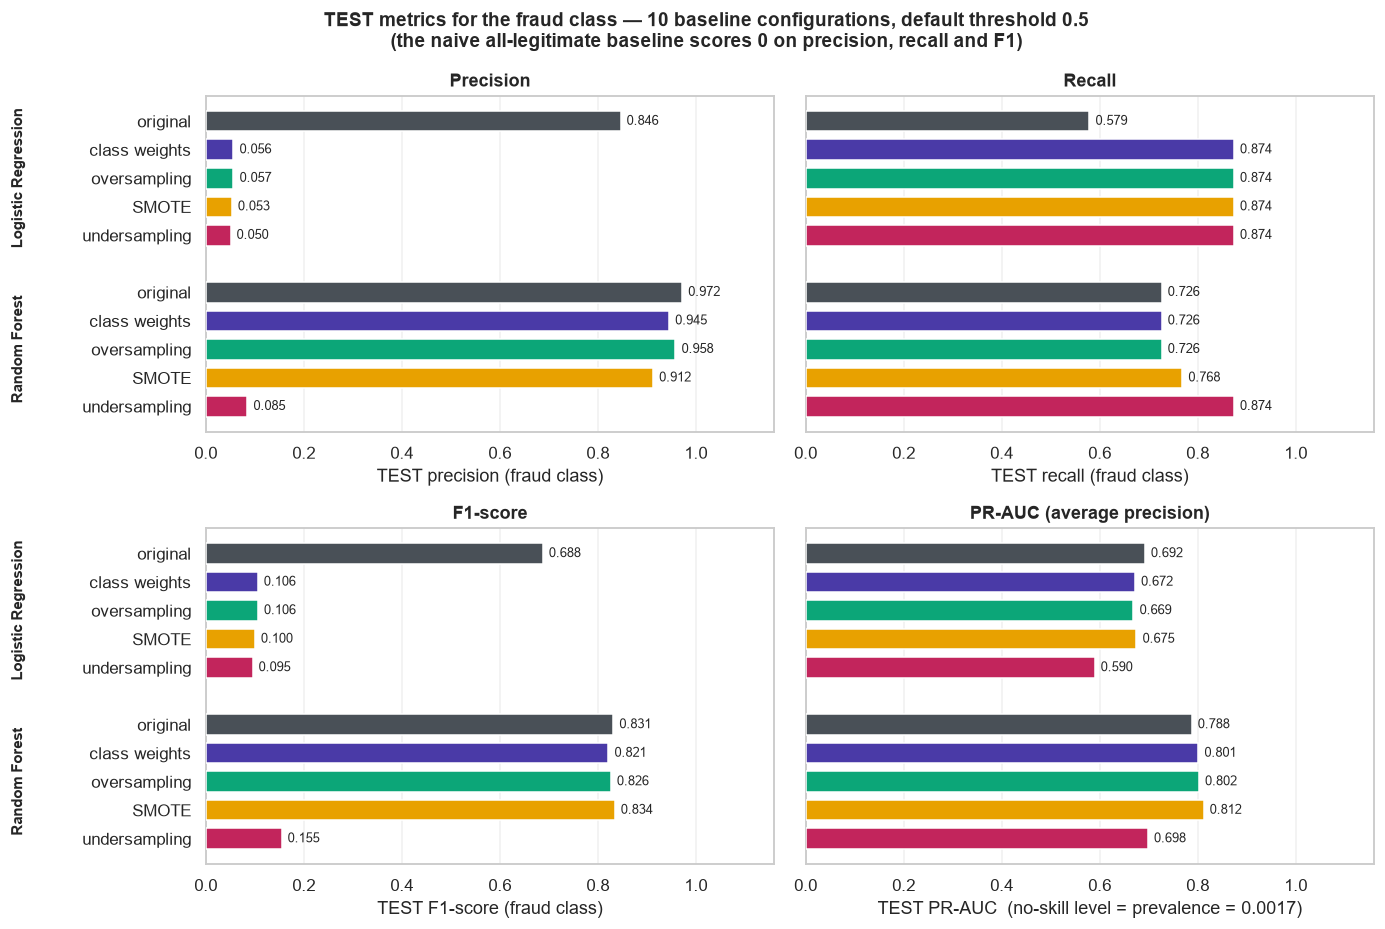

In [25]:
order = [(m, s) for m in mt.MODELS for s in mt.STRATEGIES]
short = {"original": "original", "class_weight": "class weights", "oversample": "oversampling",
         "smote": "SMOTE", "undersample": "undersampling"}
y_positions = [i if i < 5 else i + 1 for i in range(10)]           # gap between the model blocks
y_labels = [short[s] for _, s in order]

fig, axes = plt.subplots(2, 2, figsize=(12.5, 8.6), sharey=True)
panels = [("precision", "Precision"), ("recall", "Recall"), ("f1", "F1-score"), ("pr_auc", "PR-AUC (average precision)")]
xlabels = {"precision": "TEST precision (fraud class)", "recall": "TEST recall (fraud class)",
           "f1": "TEST F1-score (fraud class)",
           "pr_auc": f"TEST PR-AUC  (no-skill level = prevalence = {naive_metrics['pr_auc']:.4f})"}

for ax, (metric, title) in zip(axes.ravel(), panels):
    values = [results[key].test_metrics[metric] for key in order]
    colors = [STRATEGY_STYLE[s]["color"] for _, s in order]
    ax.barh(y_positions, values, color=colors, height=0.72, zorder=3)
    for y, v in zip(y_positions, values):
        ax.annotate(f"{v:.3f}", xy=(v, y), xytext=(4, 0), textcoords="offset points",
                    va="center", fontsize=8.5)
    ax.set_xlim(0, 1.16)
    ax.set_title(title)
    ax.set_xlabel(xlabels[metric])
    ax.grid(axis="y", visible=False)

axes[0, 0].invert_yaxis()           # once: the y-axis is shared, so a second call would undo it
for ax in axes[:, 0]:
    ax.set_yticks(y_positions, y_labels)
    ax.annotate("Logistic Regression", xy=(-0.33, 2), xycoords=("axes fraction", "data"),
                rotation=90, va="center", ha="center", fontsize=10, fontweight="bold")
    ax.annotate("Random Forest", xy=(-0.33, 8), xycoords=("axes fraction", "data"),
                rotation=90, va="center", ha="center", fontsize=10, fontweight="bold")

fig.suptitle("TEST metrics for the fraud class — 10 baseline configurations, default threshold 0.5\n"
             "(the naive all-legitimate baseline scores 0 on precision, recall and F1)",
             fontsize=12.5, fontweight="bold")
fig.tight_layout()
fig.savefig(VIZ_DIR / "11_model_metric_comparison.png")
plt.show()

---
## 16. Confusion Matrices

All five strategies are shown for each model, rather than one "best" configuration per model:
picking which matrix to display by its test score would itself be a test-set selection. Cell shading
is **row-normalised** — the share of each actual class — because with 56,651 legitimate and 95
fraudulent rows, shading by raw count would render the entire fraud row as blank.

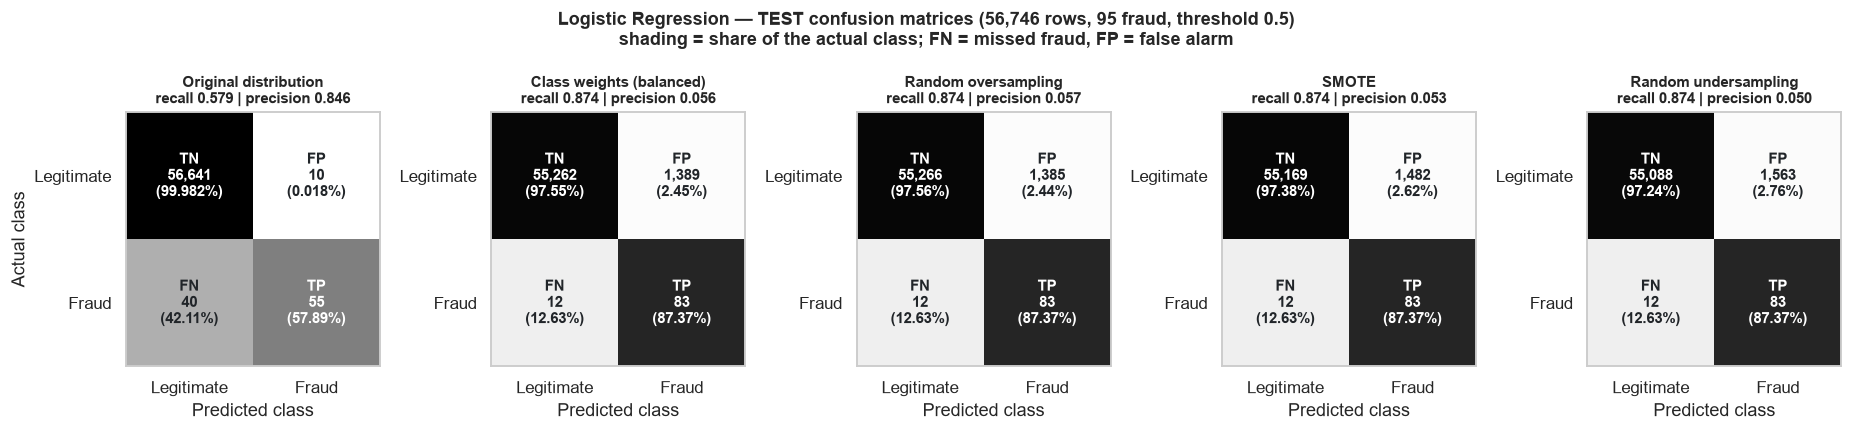

In [26]:
def share_text(share):
    """Percent with enough precision that a tiny share is never displayed as 0% or 100%."""
    pct = share * 100
    if 0 < pct < 0.1 or 99.9 < pct < 100:
        return f"{pct:.3f}%"
    return f"{pct:.2f}%"


def plot_confusion_row(model, filename):
    fig, axes = plt.subplots(1, 5, figsize=(17, 3.9))
    for ax, strategy in zip(axes, mt.STRATEGIES):
        m = results[(model, strategy)].test_metrics
        counts = np.array([[m["tn"], m["fp"]], [m["fn"], m["tp"]]])
        row_share = counts / counts.sum(axis=1, keepdims=True)
        ax.imshow(row_share, cmap="Greys", vmin=0, vmax=1)
        for i in range(2):
            for j in range(2):
                ink = "white" if row_share[i, j] > 0.55 else "#212529"
                label = ["TN", "FP", "FN", "TP"][i * 2 + j]
                ax.text(j, i, f"{label}\n{counts[i, j]:,}\n({share_text(row_share[i, j])})",
                        ha="center", va="center", fontsize=9.5, color=ink, fontweight="bold")
        ax.set_xticks([0, 1], ["Legitimate", "Fraud"])
        ax.set_yticks([0, 1], ["Legitimate", "Fraud"])
        ax.set_xlabel("Predicted class")
        if strategy == "original":
            ax.set_ylabel("Actual class")
        ax.set_title(f"{mt.STRATEGY_LABELS[strategy]}\nrecall {m['recall']:.3f} | precision {m['precision']:.3f}",
                     fontsize=9.5)
        ax.grid(False)
    fig.suptitle(f"{mt.MODEL_LABELS[model]} — TEST confusion matrices (56,746 rows, 95 fraud, threshold 0.5)\n"
                 "shading = share of the actual class; FN = missed fraud, FP = false alarm",
                 fontsize=12, fontweight="bold")
    fig.tight_layout()
    fig.savefig(VIZ_DIR / filename)
    plt.show()


plot_confusion_row("logistic_regression", "12_confusion_matrix_logistic_regression.png")

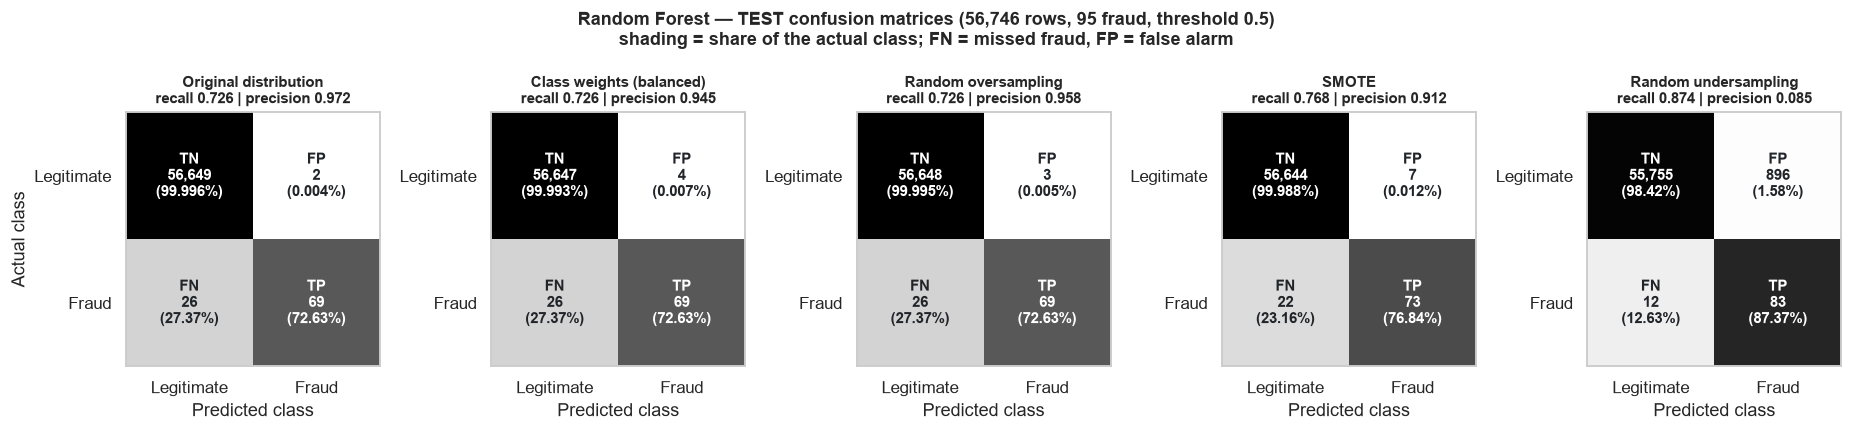

In [27]:
plot_confusion_row("random_forest", "13_confusion_matrix_random_forest.png")

In [28]:
cm_table = test_table[["tn", "fp", "fn", "tp"]].copy()
cm_table["frauds missed (FN / 95)"] = cm_table["fn"] / 95 * 100
cm_table["false alarms per fraud caught (FP / TP)"] = cm_table["fp"] / cm_table["tp"].replace(0, np.nan)
print("TEST confusion counts")
cm_table.style.format({"frauds missed (FN / 95)": "{:.2f}%",
                       "false alarms per fraud caught (FP / TP)": "{:.3f}",
                       "tn": "{:,}", "fp": "{:,}", "fn": "{:,}", "tp": "{:,}"})

TEST confusion counts


**What the matrices make concrete.**

* The difference between the two behaviour families is almost entirely in the **FP cell**: 2–10 false alarms versus 896–1,563. The fraud row (FN / TP) moves far less — between 12 and 40 missed frauds across all ten.
* **False alarms per fraud caught** ranges from **0.029** (forest, original: 2 FP for 69 TP) to **18.831** (logistic regression, undersampling: 1,563 FP for 83 TP). For an analyst reviewing alerts, that is the difference between almost every alert being real and almost every alert being noise.
* **Missed fraud** ranges from **12** (five configurations) to **40** (logistic regression, original). The high-recall configurations all stop at 12 missed; no configuration at the default threshold gets below that — section 19.3 looks at why.

Which cell matters more is a business decision about the relative cost of a missed fraud and a blocked customer. That cost ratio is not in the data, and Phase 3 does not assume one.

---
## 17. Precision-Recall Analysis

Curves are drawn on the **test set for evaluation and visualisation only**. No threshold is read off
them. The marker on each curve is where the default 0.5 threshold places that configuration — it
shows where the fixed operating point sits, not where it should be moved to.

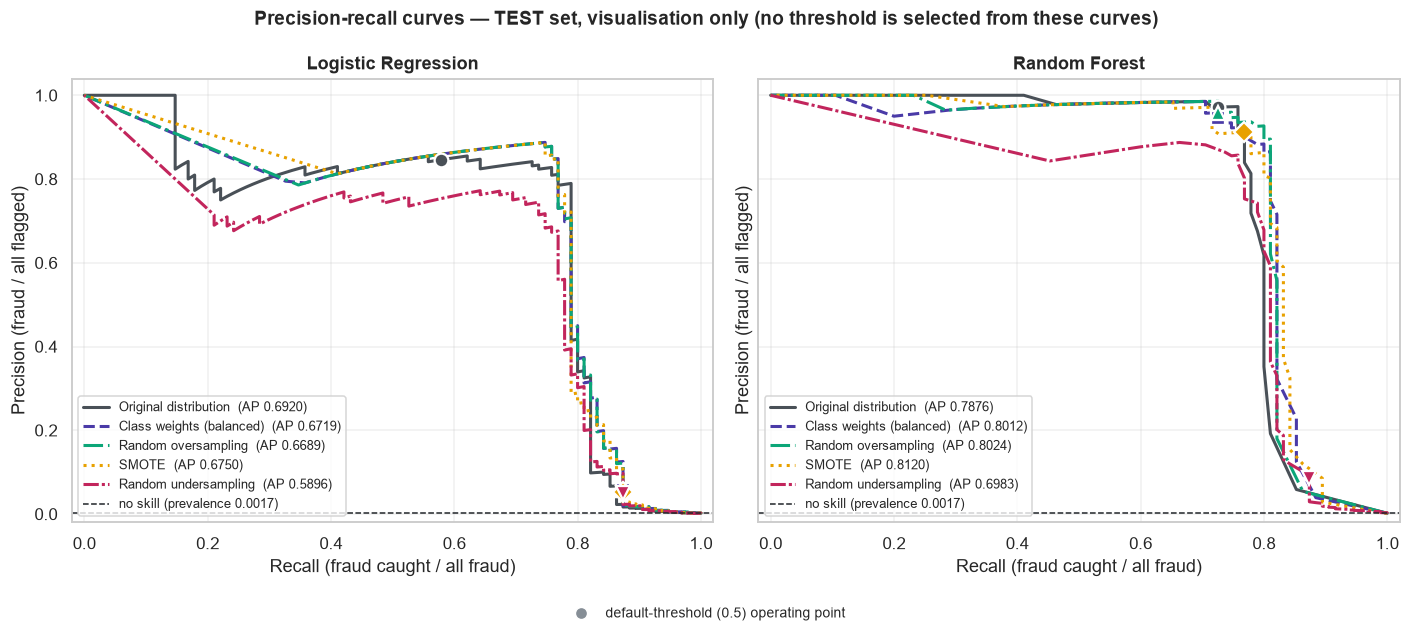

In [29]:
def plot_curves(kind, filename):
    fig, axes = plt.subplots(1, 2, figsize=(13, 5.6), sharey=True)
    for ax, model in zip(axes, mt.MODELS):
        for strategy in mt.STRATEGIES:
            r = results[(model, strategy)]
            style = STRATEGY_STYLE[strategy]
            if kind == "pr":
                prec, rec, _ = precision_recall_curve(y_test, r.test_proba, pos_label=1)
                ax.plot(rec, prec, color=style["color"], ls=style["ls"], linewidth=2,
                        label=f"{mt.STRATEGY_LABELS[strategy]}  (AP {r.test_metrics['pr_auc']:.4f})")
                op = (r.test_metrics["recall"], r.test_metrics["precision"])
            else:
                fpr, tpr, _ = roc_curve(y_test, r.test_proba, pos_label=1)
                ax.plot(fpr, tpr, color=style["color"], ls=style["ls"], linewidth=2,
                        label=f"{mt.STRATEGY_LABELS[strategy]}  (AUC {r.test_metrics['roc_auc']:.4f})")
                m = r.test_metrics
                op = (m["fp"] / (m["fp"] + m["tn"]), m["recall"])
            ax.plot(*op, marker=style["marker"], markersize=9, color=style["color"],
                    markeredgecolor="white", markeredgewidth=1.5, linestyle="none", zorder=5)
        if kind == "pr":
            ax.axhline(naive_metrics["pr_auc"], color="#212529", linestyle="--", linewidth=1,
                       label=f"no skill (prevalence {naive_metrics['pr_auc']:.4f})")
            ax.set_xlabel("Recall (fraud caught / all fraud)")
            ax.set_ylabel("Precision (fraud / all flagged)")
            ax.set_ylim(-0.02, 1.04)
            ax.legend(loc="lower left", fontsize=8.3, frameon=True)
        else:
            ax.plot([0, 1], [0, 1], color="#212529", linestyle="--", linewidth=1, label="no skill (AUC 0.5)")
            ax.set_xlabel("False-positive rate (false alarms / all legitimate)")
            ax.set_ylabel("True-positive rate = recall")
            ax.set_ylim(-0.02, 1.02)
            ax.legend(loc="lower right", fontsize=8.3, frameon=True)
        ax.set_xlim(-0.02, 1.02)
        ax.set_title(mt.MODEL_LABELS[model])

    handles = [Line2D([], [], marker="o", color="#868e96", linestyle="none", markersize=8,
                      markeredgecolor="white", label="default-threshold (0.5) operating point")]
    fig.legend(handles=handles, loc="lower center", ncol=1, frameon=False, fontsize=9,
               bbox_to_anchor=(0.5, -0.03))
    title = ("Precision-recall curves" if kind == "pr" else "ROC curves")
    fig.suptitle(f"{title} — TEST set, visualisation only (no threshold is selected from these curves)",
                 fontsize=12.5, fontweight="bold")
    fig.tight_layout(rect=(0, 0.03, 1, 1))
    fig.savefig(VIZ_DIR / filename)
    plt.show()


plot_curves("pr", "14_precision_recall_curves.png")

In [30]:
pr_table = pd.DataFrame({
    "TEST PR-AUC": test_table["pr_auc"],
    "TEST precision @0.5": test_table["precision"],
    "TEST recall @0.5": test_table["recall"],
    "PR-AUC / no-skill": test_table["pr_auc"] / naive_metrics["pr_auc"],
})
pr_table.style.format({"TEST PR-AUC": "{:.6f}", "TEST precision @0.5": "{:.6f}",
                       "TEST recall @0.5": "{:.6f}", "PR-AUC / no-skill": "{:,.1f}x"})

**Reading the curves.**

* **Every forest curve except undersampling sits above every logistic-regression curve** across most of the recall range, which is what the PR-AUC gap (0.788–0.812 vs 0.590–0.692) summarises.
* **The default-threshold markers sit in very different places on similar curves.** For logistic regression, the original-distribution marker is at recall ≈ 0.58, while the four rebalanced markers are pushed far down the right-hand cliff, at recall ≈ 0.87 and precision ≈ 0.05. The curves themselves overlap closely — rebalancing mostly slid the operating point along a similar curve rather than lifting it.
* **Both families fall off a cliff near recall ≈ 0.8.** Up to roughly 75–80% recall, precision stays high; beyond it, every extra fraud caught costs a steep rise in false alarms. That shape is consistent with section 19.3: a subset of frauds is ranked among legitimate traffic by every model.
* Every configuration's PR-AUC is **350–485×** the no-skill level of 0.001674.

The curves suggest that a different threshold could give a better trade-off for several configurations — for example, the logistic-regression curves hold precision around 0.8–0.88 until recall ≈ 0.75. **That observation is not acted on.** Choosing a threshold from the test curve would turn the test set into a tuning set; Phase 4 must choose thresholds by cross-validation on the training data.

---
## 18. ROC Analysis

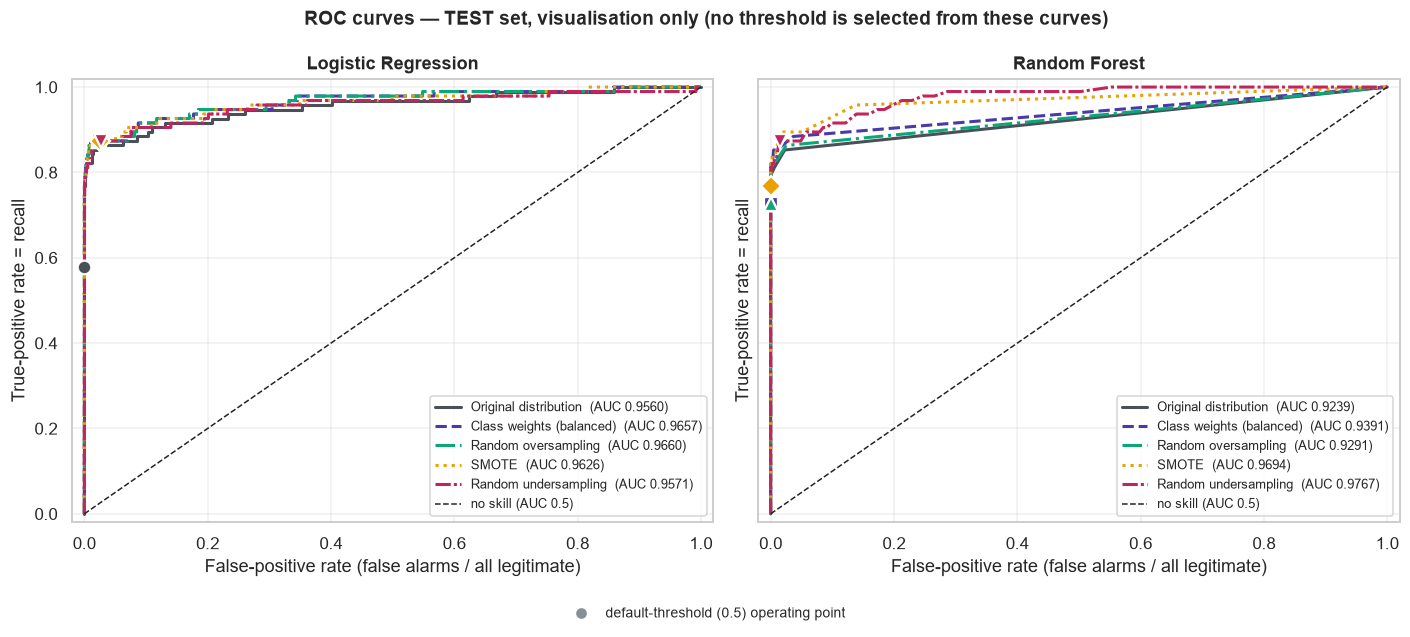

In [31]:
plot_curves("roc", "15_roc_curves.png")

In [32]:
roc_vs_pr = pd.DataFrame({
    "TEST ROC-AUC": test_table["roc_auc"],
    "TEST PR-AUC": test_table["pr_auc"],
    "ROC-AUC rank": test_table["roc_auc"].rank(ascending=False, method="min").astype(int),
    "PR-AUC rank": test_table["pr_auc"].rank(ascending=False, method="min").astype(int),
    "TEST false-positive rate @0.5": test_table["fp"] / (test_table["fp"] + test_table["tn"]),
    "TEST FP count @0.5": test_table["fp"],
})
roc_vs_pr.style.format({"TEST ROC-AUC": "{:.6f}", "TEST PR-AUC": "{:.6f}",
                        "TEST false-positive rate @0.5": "{:.4%}", "TEST FP count @0.5": "{:,}"})

In [33]:
ties = pd.DataFrame([{
    "model": mt.MODEL_LABELS[m], "strategy": mt.STRATEGY_LABELS[s],
    "distinct TEST scores": len(np.unique(results[(m, s)].test_proba)),
    "frauds scored exactly 0": int((results[(m, s)].test_proba[fraud_mask] == 0).sum()),
    "legitimate scored exactly 0": int((results[(m, s)].test_proba[legit_mask] == 0).sum()),
} for m, s in order]).set_index(["model", "strategy"])
print("How finely each configuration ranks the TEST set. Random-forest scores are vote fractions;")
print("a fraud that receives zero votes is tied with every legitimate transaction that also received zero.")
ties.style.format("{:,}")

How finely each configuration ranks the TEST set. Random-forest scores are vote fractions;
a fraud that receives zero votes is tied with every legitimate transaction that also received zero.


**ROC-AUC disagrees with PR-AUC, and the disagreement is instructive.**

| | ROC-AUC rank | PR-AUC rank | FP @ 0.5 |
|---|---|---|---|
| Random forest, undersampling | **1st** (0.976697) | 5th (0.698284) | 896 |
| Random forest, original | **10th** (0.923949) | 4th (0.787618) | 2 |

The configuration with the highest ROC-AUC raises 896 false alarms at the default threshold; the one with the *lowest* ROC-AUC raises 2 and has the highest precision in the phase. All ten ROC curves hug the top-left corner and look excellent — with 56,651 legitimate transactions, even the 1,563 false alarms of the worst configuration amount to a false-positive rate of only **2.76%**, a sliver of the ROC x-axis.

The tie table explains why the forests' ROC-AUC is comparatively low. Logistic regression gives almost every test transaction a distinct score (56,697–56,746 distinct values) and scores no fraud at exactly 0. The fully grown forests produce only **53–96** distinct scores across 56,746 transactions: on the original data, **14 of the 95 frauds** receive zero votes and are tied with **55,348** legitimate transactions that also received zero. SMOTE cuts that to **4** frauds at zero (ROC-AUC **0.969390**), and undersampling to **0** (ROC-AUC **0.976697**, the highest) — which tracks the ROC-AUC ranking of the forests closely. ROC-AUC integrates over the entire ranking, including that bottom tail where tied frauds and legitimate transactions cannot be separated; PR-AUC is dominated by the high-score region where fraud is actually flagged. This is why ROC-AUC is recorded but **does not replace PR-AUC** as the primary ranking metric here.

---
## 19. Error Analysis

Descriptive only. Where missed frauds differ from caught frauds on some feature, that is a
description of *which* transactions the models find hard, not an explanation of *why* — and it is
certainly not a claim that a feature causes fraud or causes detection.

### 19.1 Error counts and rates — TEST

In [34]:
errors = pd.DataFrame({
    "TP (fraud caught)": test_table["tp"],
    "FN (fraud missed)": test_table["fn"],
    "FP (false alarm)": test_table["fp"],
    "TN": test_table["tn"],
    "fraud recall": test_table["recall"],
    "fraud precision": test_table["precision"],
    "% of fraud missed": test_table["fn"] / 95 * 100,
    "% of legitimate flagged": test_table["fp"] / 56_651 * 100,
})
errors.style.format({"TP (fraud caught)": "{:,}", "FN (fraud missed)": "{:,}", "FP (false alarm)": "{:,}",
                     "TN": "{:,}", "fraud recall": "{:.6f}", "fraud precision": "{:.6f}",
                     "% of fraud missed": "{:.2f}%", "% of legitimate flagged": "{:.4f}%"})

### 19.2 Transaction amount by outcome — TEST

`Amount` in its original units (taken from the unscaled `X_test`), for the frauds each configuration
caught, the frauds it missed, and the legitimate transactions it flagged.

In [35]:
amount_test = X_test["Amount"].to_numpy()

amount_rows = []
for (model, strategy), r in results.items():
    pred = r.test_pred
    for outcome, mask in (("detected fraud (TP)", fraud_mask & (pred == 1)),
                          ("missed fraud (FN)", fraud_mask & (pred == 0)),
                          ("false alarm (FP)", legit_mask & (pred == 1))):
        values = amount_test[mask]
        amount_rows.append({
            "model": mt.MODEL_LABELS[model], "strategy": mt.STRATEGY_LABELS[strategy], "outcome": outcome,
            "count": int(mask.sum()),
            "mean": values.mean() if len(values) else np.nan,
            "median": np.median(values) if len(values) else np.nan,
            "min": values.min() if len(values) else np.nan,
            "max": values.max() if len(values) else np.nan,
        })

amount_by_outcome = pd.DataFrame(amount_rows).set_index(["model", "strategy", "outcome"])
print("For reference - all 95 TEST frauds: "
      f"mean {amount_test[fraud_mask].mean():.2f}, median {np.median(amount_test[fraud_mask]):.2f}, "
      f"max {amount_test[fraud_mask].max():.2f}")
print("               all 56,651 TEST legitimate: "
      f"mean {amount_test[legit_mask].mean():.2f}, median {np.median(amount_test[legit_mask]):.2f}")
amount_by_outcome.style.format({"count": "{:,}", "mean": "{:,.2f}", "median": "{:,.2f}",
                                "min": "{:,.2f}", "max": "{:,.2f}"}, na_rep="-")

For reference - all 95 TEST frauds: mean 155.43, median 12.31, max 1809.68
               all 56,651 TEST legitimate: mean 88.70, median 21.60


**Amount by outcome — descriptive only.**

* **In nine of ten configurations, missed frauds tend to be small.** For every high-recall configuration the 12 missed frauds have a median amount of **1.48** (max 1,096.99), against **18.00** for the 83 caught. For the forests on original / weighted / oversampled data the 26 missed frauds have median **3.77** against **33.59** for the 69 caught; for the SMOTE forest, **5.89** against **18.00**. Across all 95 test frauds the median is **12.31**.
* **The exception is logistic regression on the original distribution**, where the pattern reverses: its 40 missed frauds have median **15.16**, *above* the **5.91** of the 55 it catches. The small-amount pattern is therefore not a universal property of the hard frauds.
* **The mean tells a different story from the median.** Missed frauds have a *higher* mean amount than caught ones in **every** configuration (e.g. 216.55 vs 146.60), because a few large frauds are missed too. Amount alone does not describe which frauds are hard.
* **False alarms in the rebalanced models are ordinary-looking transactions**: median **10.00–19.99**, close to the legitimate median of 21.60. The single largest transaction in the dataset (**25,691.16**, legitimate) is among the false alarms of seven configurations — every logistic regression, the forest on the original data and the undersampled forest — an extreme `Amount` value flagged by models that include `Amount` as a feature. The weighted, oversampled and SMOTE forests do not flag it.

None of this says amount *causes* detection or non-detection. It says which transactions ended up where.

### 19.3 Which frauds are hard? Agreement across all ten configurations

For each of the 95 test frauds, count how many of the ten configurations missed it. A fraud missed by
every configuration is one that none of these baselines, at the default threshold, separates from
legitimate traffic.

In [36]:
fraud_positions = np.flatnonzero(fraud_mask)
miss_matrix = np.column_stack([results[key].test_pred[fraud_positions] == 0 for key in order])
miss_count = miss_matrix.sum(axis=1)

miss_distribution = pd.Series(miss_count).value_counts().reindex(range(11), fill_value=0)
miss_distribution.index.name = "configurations that missed it (of 10)"
print("TEST frauds by number of configurations that missed them:")
print(miss_distribution.rename("frauds").to_string())
print()
print(f"caught by all 10 configurations : {int((miss_count == 0).sum())}")
print(f"missed by all 10 configurations : {int((miss_count == 10).sum())}")
print(f"mixed                           : {int(((miss_count > 0) & (miss_count < 10)).sum())}")

TEST frauds by number of configurations that missed them:
configurations that missed it (of 10)
0     55
1     13
2      1
3      0
4      5
5      8
6      1
7      0
8      0
9      1
10    11

caught by all 10 configurations : 55
missed by all 10 configurations : 11
mixed                           : 29


In [37]:
fraud_frame = X_test.iloc[fraud_positions][["Amount", "V14", "V17", "V12", "V10"]].copy()
fraud_frame["group"] = np.select([miss_count == 0, miss_count == 10],
                                 ["caught by all 10", "missed by all 10"], default="mixed")
legit_reference = X_test.loc[legit_mask, ["Amount", "V14", "V17", "V12", "V10"]].median().rename("median")

profile = fraud_frame.groupby("group")[["Amount", "V14", "V17", "V12", "V10"]].median()
profile.loc["TEST legitimate (reference)"] = legit_reference
profile.insert(0, "frauds", fraud_frame["group"].value_counts().reindex(profile.index).fillna(56_651).astype(int))
print("Median feature values by group (raw, unscaled units). V14/V17/V12/V10 are the components")
print("Phase 1 found most separated between the classes; Amount is in original currency units.")
profile

Median feature values by group (raw, unscaled units). V14/V17/V12/V10 are the components
Phase 1 found most separated between the classes; Amount is in original currency units.


,frauds,Amount,V14,V17,V12,V10
group,,,,,,
caught by all 10,55,5.910000,-7.914989,-8.697777,-7.128251,-5.927359
missed by all 10,11,1.790000,-0.007791,0.120608,-0.005423,-0.150129
mixed,29,18.000000,-3.822894,-2.941876,-2.824946,-1.987773
TEST legitimate (reference),56651,21.600000,0.057199,-0.066291,0.144630,-0.090537


In [38]:
missed_sets = {key: frozenset(fraud_positions[results[key].test_pred[fraud_positions] == 0]) for key in order}
lr_rebalanced_keys = [("logistic_regression", s) for s in ("class_weight", "oversample", "smote", "undersample")]
same_lr = len({missed_sets[k] for k in lr_rebalanced_keys}) == 1
rf_default_keys = [("random_forest", s) for s in ("original", "class_weight", "oversample")]
same_rf = len({missed_sets[k] for k in rf_default_keys}) == 1

print("LR class weights / oversampling / SMOTE / undersampling miss the identical set of frauds:", same_lr)
print("RF original / class weights / oversampling miss the identical set of frauds          :", same_rf)
print()
reference = missed_sets[("logistic_regression", "class_weight")]
print(f"frauds missed by LR class weights ({len(reference)}):")
for key in order:
    overlap = len(missed_sets[key] & reference)
    print(f"  {mt.MODEL_LABELS[key[0]]:<20} {mt.STRATEGY_LABELS[key[1]]:<26} misses {len(missed_sets[key]):>2}, "
          f"of which {overlap:>2} are also missed by LR class weights")

LR class weights / oversampling / SMOTE / undersampling miss the identical set of frauds: True
RF original / class weights / oversampling miss the identical set of frauds          : False

frauds missed by LR class weights (12):
  Logistic Regression  Original distribution      misses 40, of which 12 are also missed by LR class weights
  Logistic Regression  Class weights (balanced)   misses 12, of which 12 are also missed by LR class weights
  Logistic Regression  Random oversampling        misses 12, of which 12 are also missed by LR class weights
  Logistic Regression  SMOTE                      misses 12, of which 12 are also missed by LR class weights
  Logistic Regression  Random undersampling       misses 12, of which 12 are also missed by LR class weights
  Random Forest        Original distribution      misses 26, of which 12 are also missed by LR class weights
  Random Forest        Class weights (balanced)   misses 26, of which 12 are also missed by LR class weights
  Random

**A hard core of frauds that no baseline catches.**

* **55 of 95** test frauds are caught by all ten configurations; **11** are missed by all ten; **29** are caught by some and not others.
* The four rebalanced logistic regressions miss **the identical 12 frauds** — they differ only in their false alarms. Every one of those 12 is also missed by logistic regression on the original data and by the four non-undersampled forests; the undersampled forest misses 11 of them plus one other. The forests on original, weighted and oversampled data each miss 26, but **not the same 26** — equal counts, different transactions.
* The 11 always-missed frauds are, on the four components Phase 1 found most separated between the classes, **indistinguishable from legitimate traffic**: their medians (`V14` −0.008, `V17` 0.121, `V12` −0.005, `V10` −0.150) sit essentially on the legitimate medians (0.057, −0.066, 0.145, −0.091), whereas the always-caught frauds sit far away (−7.91, −8.70, −7.13, −5.93). Their median amount is **1.79**.
* The 29 'mixed' frauds sit in between on every one of those components — the region where configurations disagree.

Descriptively: the frauds these baselines miss are the ones that *look* legitimate on the features that most separate the classes. That is not a defect a resampling strategy can fix at the default threshold, and it bounds what threshold tuning in Phase 4 can achieve — pushing recall past 0.87 means reaching into a region where fraud and legitimate transactions overlap, at a steep cost in false alarms.

### Visualisation 16 — error trade-off and hard-fraud summary

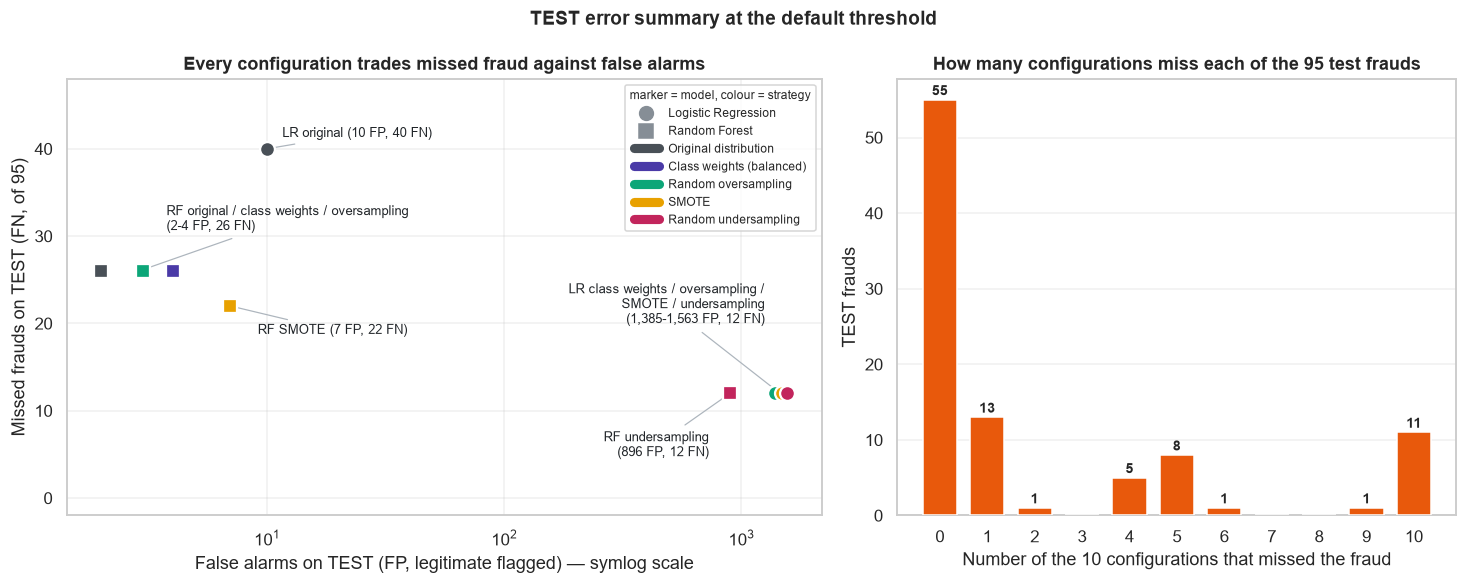

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.4), gridspec_kw={"width_ratios": [1.35, 1]})

ax = axes[0]
label_offsets = {}
for (model, strategy), r in results.items():
    m = r.test_metrics
    style = STRATEGY_STYLE[strategy]
    ax.scatter(m["fp"], m["fn"], s=95, color=style["color"], marker=MODEL_MARKER[model],
               edgecolor="white", linewidth=1.5, zorder=4)


def _m(model, strategy):
    return results[(model, strategy)].test_metrics


def cluster_label(keys, text, dx, dy, ha="left"):
    xs = [_m(*k)["fp"] for k in keys]
    ys = [_m(*k)["fn"] for k in keys]
    anchor = (float(np.exp(np.mean(np.log(np.maximum(xs, 1))))), float(np.mean(ys)))
    ax.annotate(text, xy=anchor, xytext=(dx, dy), textcoords="offset points", fontsize=8.3,
                color="#212529", ha=ha, va="center",
                arrowprops=dict(arrowstyle="-", color="#adb5bd", linewidth=0.8))


lr_rebalanced = [("logistic_regression", s) for s in ("class_weight", "oversample", "smote", "undersample")]
rf_near_default = [("random_forest", s) for s in ("original", "class_weight", "oversample")]
cluster_label([("logistic_regression", "original")],
              f"LR original ({_m('logistic_regression', 'original')['fp']} FP, "
              f"{_m('logistic_regression', 'original')['fn']} FN)", 10, 10)
cluster_label(rf_near_default,
              "RF original / class weights / oversampling\n"
              f"({min(_m(*k)['fp'] for k in rf_near_default)}-{max(_m(*k)['fp'] for k in rf_near_default)} FP, "
              f"{_m('random_forest', 'original')['fn']} FN)", 18, 34)
cluster_label([("random_forest", "smote")],
              f"RF SMOTE ({_m('random_forest', 'smote')['fp']} FP, {_m('random_forest', 'smote')['fn']} FN)",
              18, -16)
cluster_label([("random_forest", "undersample")],
              f"RF undersampling\n({_m('random_forest', 'undersample')['fp']:,} FP, "
              f"{_m('random_forest', 'undersample')['fn']} FN)", -14, -34, ha="right")
cluster_label(lr_rebalanced,
              "LR class weights / oversampling /\nSMOTE / undersampling\n"
              f"({min(_m(*k)['fp'] for k in lr_rebalanced):,}-{max(_m(*k)['fp'] for k in lr_rebalanced):,} FP, "
              f"{_m('logistic_regression', 'class_weight')['fn']} FN)", -10, 58, ha="right")
ax.set_xscale("symlog", linthresh=1)
ax.set_xlabel("False alarms on TEST (FP, legitimate flagged) — symlog scale")
ax.set_ylabel("Missed frauds on TEST (FN, of 95)")
ax.set_title("Every configuration trades missed fraud against false alarms")
ax.set_ylim(-2, max(r.test_metrics["fn"] for r in results.values()) + 8)
model_handles = [Line2D([], [], marker=MODEL_MARKER[mm], color="#868e96", linestyle="none", markersize=9,
                        label=mt.MODEL_LABELS[mm]) for mm in mt.MODELS]
# Colour bars rather than square markers, so no strategy swatch can be misread as "random forest".
strategy_handles = [Line2D([], [], color=STRATEGY_STYLE[s]["color"], linewidth=6,
                           label=mt.STRATEGY_LABELS[s]) for s in mt.STRATEGIES]
ax.legend(handles=model_handles + strategy_handles, fontsize=8, frameon=True, loc="upper right",
          title="marker = model, colour = strategy", title_fontsize=8)
ax.grid(axis="both", alpha=0.3)

ax = axes[1]
bars = ax.bar(miss_distribution.index, miss_distribution.to_numpy(), color=C_FRAUD, width=0.72, zorder=3)
for bar, value in zip(bars, miss_distribution.to_numpy()):
    if value:
        ax.annotate(f"{value}", xy=(bar.get_x() + bar.get_width() / 2, value), xytext=(0, 3),
                    textcoords="offset points", ha="center", fontsize=9, fontweight="bold")
ax.set_xticks(range(11))
ax.set_xlabel("Number of the 10 configurations that missed the fraud")
ax.set_ylabel("TEST frauds")
ax.set_title("How many configurations miss each of the 95 test frauds")
ax.grid(axis="x", visible=False)

fig.suptitle("TEST error summary at the default threshold", fontsize=12.5, fontweight="bold")
fig.tight_layout()
fig.savefig(VIZ_DIR / "16_prediction_error_summary.png")
plt.show()

---
## 20. Automated Validation and Reproducibility

Every check returns a boolean computed from the notebook's actual state. The cell ends in an
`assert`, so a failed check stops the notebook rather than being reported quietly.

In [40]:
# Cheap re-runs for an in-notebook determinism check: the five logistic-regression configurations.
# (Random-forest determinism is verified by executing the whole notebook twice and comparing.)
lr_rerun_identical = True
for strategy in mt.STRATEGIES:
    again = mt.run_experiment("logistic_regression", strategy, split)
    first = results[("logistic_regression", strategy)]
    lr_rerun_identical &= np.array_equal(again.test_proba, first.test_proba)
    lr_rerun_identical &= np.array_equal(again.test_pred, first.test_pred)

split_again = dp.split_data(dp.load_data())
expected_sampler = {
    "oversample": {1: int((y_train == 0).sum() - (y_train == 1).sum())},
    "smote": {1: int((y_train == 0).sum() - (y_train == 1).sum())},
    "undersample": {0: int((y_train == 1).sum())},
}
all_results = list(results.values())
conv_warnings = [w for w in warning_log if w[2] == "ConvergenceWarning"]
fresh_pipelines = {(m, s): mt.build_pipeline(m, s) for m in mt.MODELS for s in mt.STRATEGIES}
# Only artefacts written during this run count: the locked Phase 5 model (models/*.joblib) exists by design
# once Phase 5 has run, and must not make this phase's "no artefact written" check fail.
model_artifacts = [p for p in list(PROJECT_DIR.rglob("*.joblib")) + list(PROJECT_DIR.rglob("*.pkl"))
                   if p.stat().st_mtime >= NOTEBOOK_START_WALL]
SHA256_FINAL = dp.sha256_of_file(DATASET_PATH)
TEST_FINGERPRINT_AFTER = frame_fingerprint(X_test, y_test)


def recall_by_hand(m):
    return m["tp"] / (m["tp"] + m["fn"])


def precision_by_hand(m):
    return m["tp"] / (m["tp"] + m["fp"]) if (m["tp"] + m["fp"]) else 0.0


checks = [
    ("1. train/test split identical to Phase 2 (index re-derived)",
     split_again.X_train.index.equals(X_train.index) and split_again.X_test.index.equals(X_test.index)),
    ("2. test row count unchanged (56,746)", len(X_test) == 56_746 and len(y_test) == 56_746),
    ("3. test class counts unchanged (56,651 / 95)",
     y_test.value_counts().sort_index().to_dict() == TEST_COUNTS_BEFORE == {0: 56_651, 1: 95}),
    ("4. no test rows reached any sampler (fitted strategy derived from training counts)",
     all(results[(m, s)].sampler_strategy == expected_sampler[s]
         for m in mt.MODELS for s in expected_sampler)),
    ("5. no target column in X", dp.TARGET_COLUMN not in X_train.columns and dp.TARGET_COLUMN not in X_test.columns),
    ("6. no NaN in any predicted probability", all(not np.isnan(r.test_proba).any() for r in all_results)),
    ("7. no infinity in any predicted probability", all(np.isfinite(r.test_proba).all() for r in all_results)),
    ("8. all predictions binary {0, 1}", all(set(np.unique(r.test_pred)) <= {0, 1} for r in all_results)),
    ("9. all probabilities within [0, 1]",
     all((r.test_proba >= 0).all() and (r.test_proba <= 1).all() for r in all_results)),
    ("10. precision/recall use fraud as positive class (matches TP-based hand calculation)",
     all(np.isclose(r.test_metrics["recall"], recall_by_hand(r.test_metrics))
         and np.isclose(r.test_metrics["precision"], precision_by_hand(r.test_metrics)) for r in all_results)),
    ("11. PR-AUC computed from probability scores, not labels",
     all(np.isclose(r.test_metrics["pr_auc"], average_precision_score(y_test, r.test_proba))
         and len(np.unique(r.test_proba)) > 2 for r in all_results)),
    ("12. ROC-AUC computed from probability scores, not labels",
     all(np.isclose(r.test_metrics["roc_auc"], roc_auc_score(y_test, r.test_proba)) for r in all_results)),
    ("13. every confusion matrix has four cells summing to 56,746",
     all(sum(r.test_metrics[k] for k in ("tn", "fp", "fn", "tp")) == 56_746 for r in all_results)),
    ("14. random_state = 42 on every classifier and sampler",
     all(p.named_steps["classifier"].random_state == 42 for p in fresh_pipelines.values())
     and all(p.named_steps["resample"].random_state == 42 for p in fresh_pipelines.values()
             if "resample" in p.named_steps)),
    ("15. raw CSV checksum unchanged", SHA256_FINAL == SHA256_INITIAL == EXPECTED_SHA256),
    ("16. predictions equal P(fraud) > 0.5 - default threshold, untuned",
     all(np.array_equal(r.test_pred, (r.test_proba > mt.DEFAULT_THRESHOLD).astype(int)) for r in all_results)),
    ("17. no ConvergenceWarning raised by any configuration", len(conv_warnings) == 0),
    ("18. test-set values and labels byte-identical to the start of the notebook",
     TEST_FINGERPRINT_AFTER == TEST_FINGERPRINT_BEFORE),
    ("19. all 10 pre-registered configurations evaluated",
     sorted(results) == sorted((m, s) for m in mt.MODELS for s in mt.STRATEGIES)),
    ("20. logistic-regression configurations reproduce exactly on re-run", bool(lr_rerun_identical)),
    ("21. no model artefact written by this notebook (.joblib / .pkl)", len(model_artifacts) == 0),
    ("22. every classifier trained on training-derived rows only",
     all(sum(r.classifier_training_counts.values()) == r.classifier_training_rows for r in all_results)
     and results[("logistic_regression", "original")].classifier_training_rows == len(y_train)),
]

validation = pd.DataFrame(checks, columns=["check", "passed"])
validation["status"] = np.where(validation["passed"], "PASS", "FAIL")
n_passed = int(validation["passed"].sum())
print(f"validation checks passed: {n_passed} / {len(validation)}")
print(f"warnings captured across all fits: {len(warning_log)} "
      f"({len(conv_warnings)} ConvergenceWarning)")
assert validation["passed"].all(), "VALIDATION FAILED:\n" + validation.loc[~validation["passed"], "check"].to_string()
validation[["check", "status"]]

validation checks passed: 22 / 22
warnings captured across all fits: 0 (0 ConvergenceWarning)


,check,status
0,1. train/test split identical to Phase 2 (inde...,PASS
1,"2. test row count unchanged (56,746)",PASS
2,"3. test class counts unchanged (56,651 / 95)",PASS
3,4. no test rows reached any sampler (fitted st...,PASS
4,5. no target column in X,PASS
5,6. no NaN in any predicted probability,PASS
6,7. no infinity in any predicted probability,PASS
7,"8. all predictions binary {0, 1}",PASS
8,"9. all probabilities within [0, 1]",PASS
9,10. precision/recall use fraud as positive cla...,PASS


In [41]:
# Reproducibility fingerprints. The notebook is executed twice from fresh kernels and these
# digests compared: identical digests mean identical probabilities AND predictions, bit for bit.
fingerprints = {}
for key in order:
    r = results[key]
    digest = hashlib.sha256()
    digest.update(np.ascontiguousarray(r.test_proba).tobytes())
    digest.update(np.ascontiguousarray(r.test_pred).tobytes())
    fingerprints[f"{mt.MODEL_LABELS[key[0]]} | {mt.STRATEGY_LABELS[key[1]]}"] = digest.hexdigest()[:16]

overall = hashlib.sha256("".join(fingerprints.values()).encode()).hexdigest()
print("per-configuration TEST prediction fingerprints (first 16 hex of SHA-256):")
for name, fp in fingerprints.items():
    print(f"  {fp}  {name}")
print()
print("combined fingerprint:", overall)

per-configuration TEST prediction fingerprints (first 16 hex of SHA-256):
  d2bbdb5c022b47d3  Logistic Regression | Original distribution
  fc57e2534ad3c6ba  Logistic Regression | Class weights (balanced)
  269ca458c432b2fe  Logistic Regression | Random oversampling
  3aa4fcedb28fe6be  Logistic Regression | SMOTE
  59d9a92b56de672c  Logistic Regression | Random undersampling
  802445af7a4a94d8  Random Forest | Original distribution
  37326a22f38df73f  Random Forest | Class weights (balanced)
  e41dbf84435a09d4  Random Forest | Random oversampling
  c768e37191075887  Random Forest | SMOTE
  67cbbdaffdb6912a  Random Forest | Random undersampling

combined fingerprint: 4ad550cd2a67f8d91815ee9191156965ece323b6bf08bd867420da4294ee65a1


In [42]:
expected_figures = {
    "11_model_metric_comparison.png": "TEST precision / recall / F1 / PR-AUC for all 10 configurations",
    "12_confusion_matrix_logistic_regression.png": "TEST confusion matrices, logistic regression, all 5 strategies",
    "13_confusion_matrix_random_forest.png": "TEST confusion matrices, random forest, all 5 strategies",
    "14_precision_recall_curves.png": "TEST precision-recall curves with default-threshold operating points",
    "15_roc_curves.png": "TEST ROC curves with default-threshold operating points",
    "16_prediction_error_summary.png": "FP-vs-FN trade-off and per-fraud miss counts across configurations",
}
inventory = pd.DataFrame([{
    "file": f, "exists": (VIZ_DIR / f).is_file(),
    "KiB": round((VIZ_DIR / f).stat().st_size / 1024, 1) if (VIZ_DIR / f).is_file() else 0,
    "purpose": p} for f, p in expected_figures.items()]).set_index("file")
assert inventory["exists"].all(), "missing figure(s)"
print("SHA-256 initial:", SHA256_INITIAL)
print("SHA-256 final  :", SHA256_FINAL)
print("raw data status:", "UNCHANGED" if SHA256_FINAL == SHA256_INITIAL else "*** MODIFIED ***")
print()
print("all Phase 3 figures written:", bool(inventory["exists"].all()))
inventory

SHA-256 initial: 76274b691b16a6c49d3f159c883398e03ccd6d1ee12d9d8ee38f4b4b98551a89
SHA-256 final  : 76274b691b16a6c49d3f159c883398e03ccd6d1ee12d9d8ee38f4b4b98551a89
raw data status: UNCHANGED

all Phase 3 figures written: True


,exists,KiB,purpose
file,,,
11_model_metric_comparison.png,True,174.800000,TEST precision / recall / F1 / PR-AUC for all ...
12_confusion_matrix_logistic_regression.png,True,152.500000,"TEST confusion matrices, logistic regression, ..."
13_confusion_matrix_random_forest.png,True,149.000000,"TEST confusion matrices, random forest, all 5 ..."
14_precision_recall_curves.png,True,189.600000,TEST precision-recall curves with default-thre...
15_roc_curves.png,True,173.400000,TEST ROC curves with default-threshold operati...
16_prediction_error_summary.png,True,124.900000,FP-vs-FN trade-off and per-fraud miss counts a...


---
## 21. Baseline Findings

*All figures below are TEST metrics at the default 0.5 threshold on 56,746 transactions containing 95 frauds, unless marked TRAIN. They are an initial baseline record, not final results.*

**1. Accuracy is uninformative, as predicted.** The naive all-legitimate model scores **0.998326** accuracy and catches **0** frauds. Five of the ten trained configurations have *lower* accuracy than that — and each of them catches **83** frauds the naive model misses.

**2. Unweighted logistic regression under-detects.** Recall **0.578947** (55 of 95), precision **0.846154**, PR-AUC **0.691967**. It misses **40** frauds.

**3. Class weighting trades precision for recall — it does not improve ranking.** For logistic regression: recall **0.578947 → 0.873684**, false alarms **10 → 1,389**, precision **0.846154 → 0.056386**, and PR-AUC slightly *lower* (**0.691967 → 0.671924**). Oversampling reproduces weighting almost exactly (1,385 FP, PR-AUC 0.668936); SMOTE adds false alarms (1,482); undersampling adds the most (1,563) and loses ranking quality (PR-AUC **0.589557**, the lowest of all ten).

**4. Random forest behaves differently.** On original, weighted and oversampled data it lands in almost the same place: **69** frauds caught each (not identical sets), **2–4** false alarms, precision **0.945–0.972**, PR-AUC **0.787618–0.802386**. Fully grown trees have pure leaves, so weights and duplicates change little at the 0.5 threshold. SMOTE moves it furthest usefully — **73** caught, **7** false alarms. Undersampling moves it into the high-recall family (83 caught, **896** false alarms) — still ~490 fewer false alarms than any logistic regression at the same recall.

**5. Strongest baseline evidence, stated per metric.**

* **Highest measured PR-AUC among the Phase 3 configurations: random forest + SMOTE, 0.811967** (also highest F1, **0.834286**).
* **Highest precision: random forest on the original distribution, 0.971831** (2 false alarms).
* **Highest fraud recall: 0.873684**, shared by five configurations, each at a cost of **896–1,563** false alarms.
* **As a family**, the four non-undersampled forests (PR-AUC 0.788–0.812) rank fraud better than every logistic-regression configuration (0.590–0.692).

**6. The margins at the top are small relative to the test set's resolution.** Random forest + SMOTE catches 73 frauds; the next three forests catch 69. That is **4 transactions**. With 95 positives, the binomial standard error of a recall near 0.75 is about **±0.044** — roughly the size of the gap. These numbers do not establish that SMOTE is better for the forest; they establish that it is worth testing properly under cross-validation.

**7. Random forests overfit their training data; logistic regression does not.** TRAIN recall **≥ 0.997** and TRAIN PR-AUC **1.000000** for four forests, against TEST recall **0.726–0.768**. Logistic regression's TRAIN–TEST recall gap is **0.03–0.05**.

**8. ROC-AUC would have pointed the wrong way.** The highest ROC-AUC (**0.976697**, forest + undersampling) belongs to a configuration with 896 false alarms and the fifth-best PR-AUC; the lowest (**0.923949**, forest on original) belongs to the most precise configuration.

**9. Errors concentrate in frauds that look legitimate.** **11** frauds are missed by all ten configurations; on `V14`/`V17`/`V12`/`V10` their medians sit on top of the legitimate medians. In nine of ten configurations, missed frauds skew toward small amounts by median (1.48–5.89 vs 12.31 for all fraud); logistic regression on the original distribution is the exception (missed median 15.16), and a few large frauds are missed everywhere.

**10. The default threshold is a large, untouched lever.** For logistic regression, rebalancing mostly moved the operating point along a similar precision-recall curve rather than lifting the curve. How much a cross-validated threshold could recover — for either family — is the central Phase 4 question.

---
## 22. Phase 3 Conclusions

**What this phase established.** Ten pre-registered baseline configurations — both model families the CodSoft brief names, each under five imbalance strategies — were trained on the Phase 2 training split and scored once on the untouched test set. Every configuration beats the naive baseline on every fraud metric. Random-forest configurations provide the strongest ranking evidence (PR-AUC up to **0.811967**) and by far the fewest false alarms; logistic regression reaches the highest recall only by flagging **1,385–1,563** legitimate transactions.

**What it did not establish.** No configuration is selected, and none should be on this evidence alone. The differences among the top forests are a handful of transactions on a 95-fraud test set; the default threshold is arbitrary for every one of them; and the forests' TRAIN metrics show they are overfitted in ways that tuning might change.

**Limitations, stated plainly.**

* **95 test frauds.** Every recall or precision figure carries roughly ±0.04–0.05 of sampling uncertainty. Differences of a few transactions are not evidence.
* **One split.** Results reflect one stratified 80/20 split. Cross-validation (Phase 4) is needed to see how stable they are.
* **Default hyperparameters and default threshold.** Neither is tuned, by design. The random forest in particular is fully grown and visibly overfitted.
* **Test-set exposure.** These test numbers have now been seen. They remain an honest record *of these ten pre-registered configurations* because nothing was changed after seeing them — but any configuration chosen or modified from here on must be justified on training-data cross-validation, and the test set should next be used only for the final evaluation.
* **No cost model.** Whether 12 missed frauds with 1,389 false alarms is better or worse than 26 missed with 2 depends on costs the dataset does not contain.
* **Scaling-strategy comparison deferred.** Phase 2's `"minimal"` and `"log_amount"` preprocessors were not compared here; that is a model-selection decision and moves to Phase 4.

**Planned for Phase 4 — for approval.** Stratified cross-validation on the training split; imbalance-strategy selection on CV PR-AUC rather than on this test set; hyperparameter tuning (notably forest depth / leaf size); threshold analysis on out-of-fold predictions; and the deferred scaling comparison. The test set stays sealed until final evaluation.

No model artefact was written, no threshold was tuned, and Phase 4 has not been started.

In [43]:
NOTEBOOK_SECONDS = time.perf_counter() - NOTEBOOK_START

print("=" * 86)
print("PHASE 3 - BASELINE CLASSIFICATION MODELS - SUMMARY".center(86))
print("=" * 86)
print(f"{'split':<30}: Phase 2, reproduced exactly - train 226,980 (378 fraud) / test 56,746 (95 fraud)")
print(f"{'configurations evaluated':<30}: {len(results)} of 10 pre-registered (2 models x 5 strategies)")
print(f"{'decision threshold':<30}: {mt.DEFAULT_THRESHOLD} (default, untuned)")
print("-" * 86)
print(f"{'TEST (fraud class)':<44}{'prec':>9}{'recall':>9}{'F1':>9}{'PR-AUC':>9}{'ROC-AUC':>9}")
for key in order:
    m = results[key].test_metrics
    name = f"{'LR' if key[0] == 'logistic_regression' else 'RF'} | {mt.STRATEGY_LABELS[key[1]]}"
    print(f"{name:<44}{m['precision']:>9.4f}{m['recall']:>9.4f}{m['f1']:>9.4f}{m['pr_auc']:>9.4f}{m['roc_auc']:>9.4f}")
m = naive_metrics
print(f"{'naive | all legitimate':<44}{m['precision']:>9.4f}{m['recall']:>9.4f}{m['f1']:>9.4f}{m['pr_auc']:>9.4f}{m['roc_auc']:>9.4f}")
print("-" * 86)
print(f"{'validation checks':<30}: {n_passed} / {len(validation)} passed")
print(f"{'figures written':<30}: {int(inventory['exists'].sum())} / {len(expected_figures)}")
print(f"{'raw data':<30}: {'UNCHANGED' if SHA256_FINAL == SHA256_INITIAL else 'MODIFIED'}")
print(f"{'prediction fingerprint':<30}: {overall[:32]}")
print(f"{'notebook runtime':<30}: {NOTEBOOK_SECONDS / 60:.1f} min")
print("-" * 86)
print("PHASE 3 STATUS:", "COMPLETE" if validation["passed"].all() and inventory["exists"].all() else "FAILED")
print("Baseline record only. No tuning, no threshold optimisation, no model persisted. Phase 4 not started.")
print("=" * 86)

                  PHASE 3 - BASELINE CLASSIFICATION MODELS - SUMMARY                  
split                         : Phase 2, reproduced exactly - train 226,980 (378 fraud) / test 56,746 (95 fraud)
configurations evaluated      : 10 of 10 pre-registered (2 models x 5 strategies)
decision threshold            : 0.5 (default, untuned)
--------------------------------------------------------------------------------------
TEST (fraud class)                               prec   recall       F1   PR-AUC  ROC-AUC
LR | Original distribution                     0.8462   0.5789   0.6875   0.6920   0.9560
LR | Class weights (balanced)                  0.0564   0.8737   0.1059   0.6719   0.9657
LR | Random oversampling                       0.0565   0.8737   0.1062   0.6689   0.9660
LR | SMOTE                                     0.0530   0.8737   0.1000   0.6750   0.9626
LR | Random undersampling                      0.0504   0.8737   0.0953   0.5896   0.9571
RF | Original distribution          